# HSE UEC Deep Dive EDA
**Using previously unexplored columns: holidays (name/type), weather (rhum, pres, tsun), population, bed capacity, and the three clinical columns recovered from blobs (surge_capacity, delayed_transfers, waiting_24h).**

| Section | Core question |
|---------|---------------|
| 1 — Day-after holiday | When exactly does the surge hit? |
| 2 — Hospital trajectories | Who is getting worse? |
| 3 — ED vs Ward split | What type of problem? |
| 4 — Per-capita | Which regions are truly underserved? |
| 5 — Trolleys per bed | Is capacity keeping up? |
| 6 — Full weather signal | What weather variables actually matter? |
| 7 — Worst days anatomy | Who drives national crises? |
| 8 — Regional inequality | Is the gap widening? |
| 9 — Volatility | Which hospitals are unpredictable? |
| 10 — Data quality | Where are the blind spots? |
| 11 — Surge capacity | When is extra capacity activated? |
| 12 — Delayed transfers | Bed block by social care failures |
| 13 — Waiting >24h | The patient safety metric |

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import pyodbc
from datetime import timedelta

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
})
PALETTE = sns.color_palette('tab10')
REGION_COLORS = dict(zip(
    ['HSE Dublin & North East', 'HSE Dublin & Midlands', 'HSE Dublin & South East',
     'HSE Mid West', 'HSE South West', 'HSE West & North West'],
    PALETTE
))

def _connstr():
    with open('local.settings.json') as f:
        return json.load(f)['Values']['SQL_CONN_STR']

def qry(sql):
    return pd.read_sql(sql, pyodbc.connect(_connstr()))

print('Setup complete.')

Setup complete.


In [2]:
# ── Load all base datasets ────────────────────────────────────────────────

# National daily totals (is_total = 1)
nat = qry('''
    SELECT report_date, total_trolleys,
           surge_capacity, delayed_transfers,
           waiting_24h, waiting_24h_75plus
    FROM dbo.hse_uec_daily
    WHERE is_total = 1
''')
nat['report_date'] = pd.to_datetime(nat['report_date'])
nat = nat.sort_values('report_date').reset_index(drop=True)
nat['year']  = nat['report_date'].dt.year
nat['month'] = nat['report_date'].dt.month
nat['dow']   = nat['report_date'].dt.dayofweek   # 0=Mon

# Hospital-level daily
hosp = qry('''
    SELECT report_date, region, hospital,
           ed_trolleys, ward_trolleys, total_trolleys,
           surge_capacity, delayed_transfers, waiting_24h
    FROM dbo.hse_uec_daily
    WHERE is_total = 0
''')
hosp['report_date'] = pd.to_datetime(hosp['report_date'])
hosp['year']  = hosp['report_date'].dt.year
hosp['month'] = hosp['report_date'].dt.month

# Public holidays only
hols = qry("SELECT holiday_date, name, local_name, types FROM ref_holidays_ie WHERE types LIKE '%Public%'")
hols['holiday_date'] = pd.to_datetime(hols['holiday_date'])

# Daily features (weather + pop + beds) — hospital level
feat = qry('''
    SELECT report_date, region, hospital, total_trolleys,
           tavg, tmin, tmax, prcp, rhum, pres, wspd, tsun,
           beds_total_ire, pop_region, is_holiday
    FROM stg.daily_features
''')
feat['report_date'] = pd.to_datetime(feat['report_date'])
feat['month'] = feat['report_date'].dt.month

# Bed capacity by sector
beds_sec = qry('SELECT year, sector, beds_total FROM ref_bed_capacity_sector')

print(f'national rows  : {len(nat):,}')
print(f'hospital rows  : {len(hosp):,}')
print(f'public holidays: {len(hols)}')
print(f'feature rows   : {len(feat):,}')
print(f'beds sectors   : {beds_sec["sector"].unique()}')

national rows  : 1,180
hospital rows  : 38,763
public holidays: 40
feature rows   : 38,763
beds sectors   : ['Privately owned hospitals' 'Publicly owned hospitals' 'Total hospitals']


---
## Section 1 — Day-After-Holiday: Proving the Surge
For every public holiday, extract trolley counts at T-2, T-1, T (holiday), T+1, T+2, T+3.  
Identify which specific holidays cause the worst day-after surge.

In [3]:
nat_ts = nat.set_index('report_date')['total_trolleys']

offsets = list(range(-2, 4))  # -2, -1, 0, 1, 2, 3
records = []
for _, row in hols.iterrows():
    hdate = row['holiday_date']
    for off in offsets:
        d = hdate + timedelta(days=off)
        if d in nat_ts.index:
            records.append({
                'holiday'     : row['local_name'],
                'holiday_date': hdate,
                'offset'      : off,
                'trolleys'    : nat_ts[d],
            })

df1 = pd.DataFrame(records)

# Build control: for T+1, compare to same weekday ±3 non-holiday weeks
hol_dates = set(hols['holiday_date'])
t1_rows = df1[df1['offset'] == 1].copy()
control = []
for _, r in t1_rows.iterrows():
    t1_date = r['holiday_date'] + timedelta(days=1)
    dow = t1_date.weekday()
    for w in [-3, -2, -1, 1, 2, 3]:
        cand = t1_date + timedelta(weeks=w)
        if cand in nat_ts.index and cand not in hol_dates:
            control.append(nat_ts[cand])

control_mean = np.mean(control)
t1_mean      = t1_rows['trolleys'].mean()
lift_pct     = (t1_mean - control_mean) / control_mean * 100

print(f'T+1 mean trolleys : {t1_mean:.0f}')
print(f'Control mean      : {control_mean:.0f}')
print(f'Day-after lift    : +{lift_pct:.1f}%  (vs matched non-holiday same weekday)')

# Average trajectory
avg_offset = df1.groupby('offset')['trolleys'].agg(['mean', 'sem']).reset_index()

# Worst holiday T+1
by_hol = df1[df1['offset'] == 1].groupby('holiday')['trolleys'].mean().sort_values(ascending=False)

T+1 mean trolleys : 307
Control mean      : 376
Day-after lift    : +-18.4%  (vs matched non-holiday same weekday)


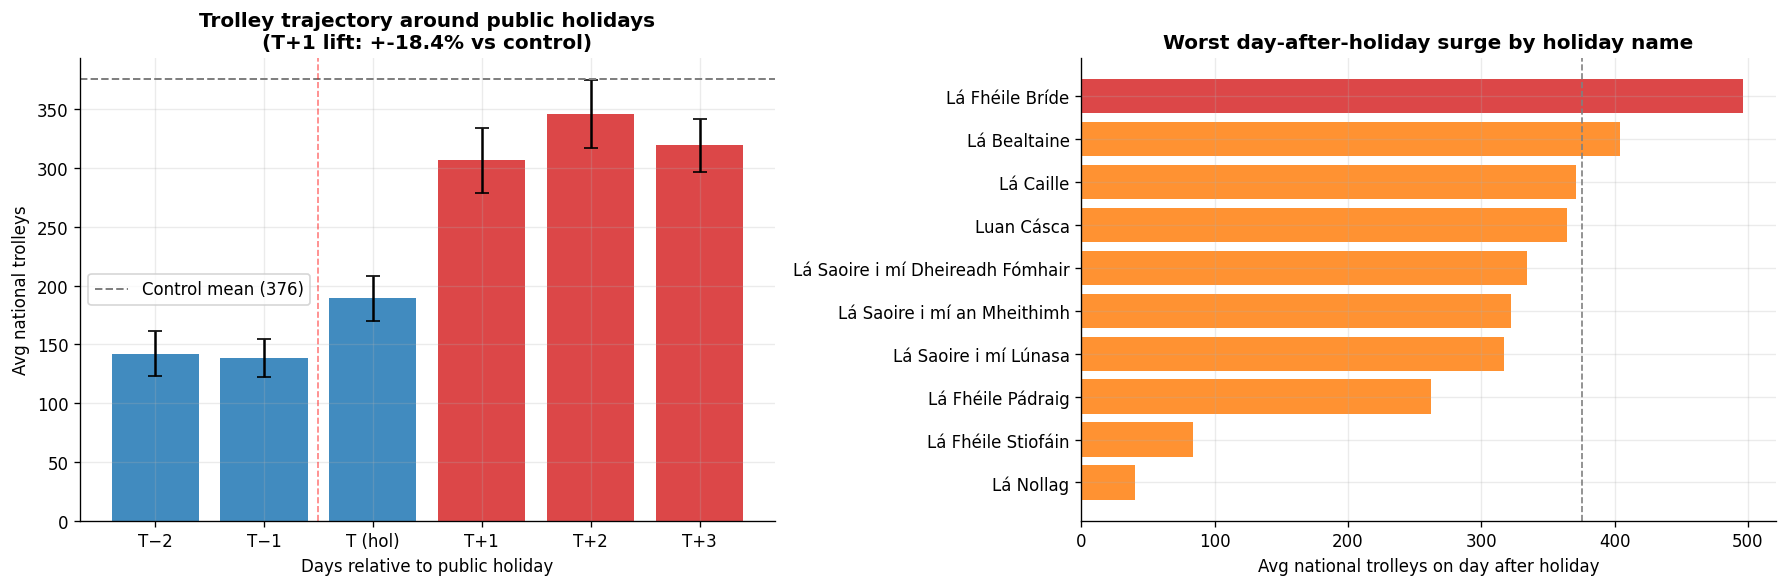

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: average trajectory
ax = axes[0]
colors = [PALETTE[3] if o >= 1 else PALETTE[0] for o in avg_offset['offset']]
bars = ax.bar(avg_offset['offset'], avg_offset['mean'], color=colors,
              yerr=avg_offset['sem'], capsize=4, alpha=0.85)
ax.axhline(control_mean, color='grey', linestyle='--', linewidth=1.2, label=f'Control mean ({control_mean:.0f})')
ax.axvline(-0.5, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xticks(offsets)
ax.set_xticklabels(['T−2', 'T−1', 'T (hol)', 'T+1', 'T+2', 'T+3'])
ax.set_xlabel('Days relative to public holiday')
ax.set_ylabel('Avg national trolleys')
ax.set_title(f'Trolley trajectory around public holidays\n(T+1 lift: +{lift_pct:.1f}% vs control)', fontweight='bold')
ax.legend()

# Right: which holidays are worst at T+1
ax2 = axes[1]
bar_colors = [PALETTE[3] if v == by_hol.max() else PALETTE[1] for v in by_hol.values]
ax2.barh(by_hol.index, by_hol.values, color=bar_colors, alpha=0.85)
ax2.set_xlabel('Avg national trolleys on day after holiday')
ax2.set_title('Worst day-after-holiday surge by holiday name', fontweight='bold')
ax2.invert_yaxis()
ax2.axvline(control_mean, color='grey', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('outputs/s1_holiday_surge.png', bbox_inches='tight')
plt.show()

---
## Section 2 — Hospital Trajectories: Improving vs Declining
Yearly average trolleys per hospital (2023 → 2024 → 2025) with linear slope.  
Quadrant scatter: avg severity vs trend direction.

In [5]:

# Yearly average per hospital (exclude 2026 — partial year)
yearly = (
    hosp[hosp['year'].isin([2023, 2024, 2025])]
    .groupby(['hospital', 'year'])['total_trolleys']
    .mean()
    .reset_index()
)

# Linear slope per hospital (year as x, avg trolleys as y)
def slope_and_mean(grp):
    if len(grp) < 2:
        return pd.Series({'slope': np.nan, 'avg': grp['total_trolleys'].mean()})
    m, _, _, _, _ = stats.linregress(grp['year'], grp['total_trolleys'])
    return pd.Series({'slope': m, 'avg': grp['total_trolleys'].mean()})

traj = yearly.groupby('hospital').apply(slope_and_mean).reset_index()
traj = traj.dropna()

# Add region — use first value per hospital (one region per hospital)
region_map = hosp.groupby('hospital')['region'].first()
traj['region'] = traj['hospital'].map(region_map)

med_avg   = traj['avg'].median()
med_slope = 0  # zero = no change

print(f'Hospitals analysed: {len(traj)}')
print(f'Getting worse (positive slope): {(traj["slope"] > 0).sum()}')
print(f'Improving (negative slope):     {(traj["slope"] < 0).sum()}')
print('\nTop 5 deteriorating:')
print(traj.nlargest(5, 'slope')[['hospital', 'avg', 'slope']].to_string(index=False))
print('\nTop 5 improving:')
print(traj.nsmallest(5, 'slope')[['hospital', 'avg', 'slope']].to_string(index=False))


Hospitals analysed: 41
Getting worse (positive slope): 6
Improving (negative slope):     21

Top 5 deteriorating:
                       hospital       avg    slope
     Galway University Hospital 24.345776 3.475114
   Our Lady of Lourdes Hospital 10.312608 2.138356
       Mayo University Hospital 13.629569 0.729960
Letterkenny University Hospital 11.268497 0.577709
         Cavan General Hospital  5.484712 0.206849

Top 5 improving:
                               hospital       avg     slope
           Tallaght University Hospital 17.811628 -5.356164
                   St. James's Hospital 14.603893 -5.178082
               Cork University Hospital 22.355404 -4.418177
                         CHI at Crumlin  2.833333 -4.333333
Mater Misericordiae University Hospital 13.785161 -3.578082


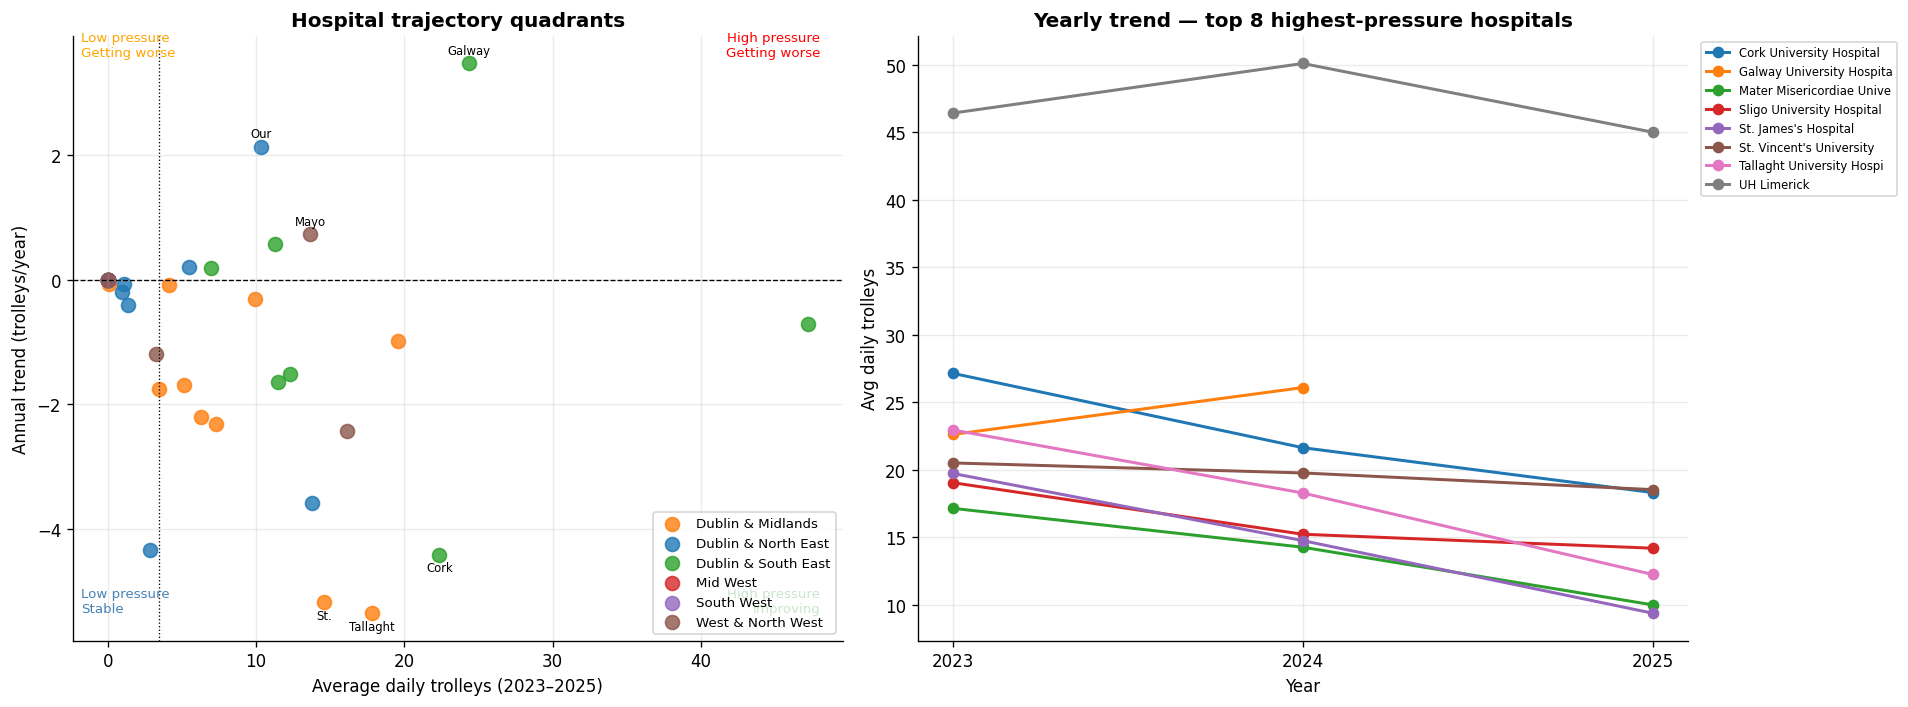

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: quadrant scatter
ax = axes[0]
for region, grp in traj.groupby('region'):
    c = REGION_COLORS.get(region, 'grey')
    ax.scatter(grp['avg'], grp['slope'], color=c, alpha=0.8, s=70, label=region.replace('HSE ', ''))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(med_avg, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Average daily trolleys (2023–2025)')
ax.set_ylabel('Annual trend (trolleys/year)')
ax.set_title('Hospital trajectory quadrants', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')

# Annotate extreme outliers
for _, r in traj.nlargest(3, 'slope').iterrows():
    ax.annotate(r['hospital'].split(' ')[0], (r['avg'], r['slope']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 4), textcoords='offset points')
for _, r in traj.nsmallest(3, 'slope').iterrows():
    ax.annotate(r['hospital'].split(' ')[0], (r['avg'], r['slope']),
                fontsize=7, ha='center', va='top',
                xytext=(0, -4), textcoords='offset points')

# Quadrant labels
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.text(xmax*0.97, ymax*0.92, 'High pressure\nGetting worse', color='red', fontsize=8, ha='right')
ax.text(xmax*0.97, ymin*0.92, 'High pressure\nImproving', color='green', fontsize=8, ha='right')
ax.text(xmin*1.0 + (med_avg-xmin)*0.1, ymax*0.92, 'Low pressure\nGetting worse', color='orange', fontsize=8)
ax.text(xmin*1.0 + (med_avg-xmin)*0.1, ymin*0.92, 'Low pressure\nStable', color='steelblue', fontsize=8)

# Right: yearly trend lines for top 8 hospitals
ax2 = axes[1]
top8 = traj.nlargest(8, 'avg')['hospital'].tolist()
piv = yearly[yearly['hospital'].isin(top8)].pivot(index='year', columns='hospital', values='total_trolleys')
for i, col in enumerate(piv.columns):
    ax2.plot(piv.index, piv[col], marker='o', color=PALETTE[i % 10],
             label=col[:25], linewidth=1.8)
ax2.set_xticks([2023, 2024, 2025])
ax2.set_xlabel('Year')
ax2.set_ylabel('Avg daily trolleys')
ax2.set_title('Yearly trend — top 8 highest-pressure hospitals', fontweight='bold')
ax2.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('outputs/s2_trajectories.png', bbox_inches='tight')
plt.show()

---
## Section 3 — ED vs Ward: Type of Problem by Hospital
ED trolleys = front-door capacity problem.  
Ward trolleys = discharge/bed management problem.  
National trend: is the ED/Ward ratio shifting over time?

In [7]:
# Filter to rows with both ED and ward data
h3 = hosp[(hosp['ed_trolleys'].notna()) & (hosp['ward_trolleys'].notna()) &
          (hosp['total_trolleys'] > 0)].copy()

# Hospital-level averages
h3_avg = h3.groupby('hospital')[['ed_trolleys', 'ward_trolleys', 'total_trolleys']].mean()
h3_avg['ed_pct']   = h3_avg['ed_trolleys']   / h3_avg['total_trolleys'] * 100
h3_avg['ward_pct'] = h3_avg['ward_trolleys'] / h3_avg['total_trolleys'] * 100
h3_avg = h3_avg.sort_values('total_trolleys', ascending=False).reset_index()

# Classify
def classify(row):
    if row['ed_pct'] > 65:   return 'ED-dominant'
    if row['ward_pct'] > 65: return 'Ward-dominant'
    return 'Mixed'

h3_avg['type'] = h3_avg.apply(classify, axis=1)
print(h3_avg[['hospital', 'ed_pct', 'ward_pct', 'type']].to_string(index=False))

# National year-over-year ED/Ward ratio
nat_split = h3[h3['year'].isin([2023, 2024, 2025])].groupby('year')[['ed_trolleys', 'ward_trolleys']].mean()
nat_split['ed_ratio'] = nat_split['ed_trolleys'] / (nat_split['ed_trolleys'] + nat_split['ward_trolleys']) * 100
print('\nNational ED% by year:')
print(nat_split[['ed_ratio']])

                               hospital     ed_pct  ward_pct          type
                            UH Limerick  32.061729 67.938271 Ward-dominant
               Cork University Hospital  74.806112 25.193888   ED-dominant
             Galway University Hospital  76.929364 23.070636   ED-dominant
      St. Vincent's University Hospital  93.156946  6.843054   ED-dominant
           Tallaght University Hospital  89.297659 10.702341   ED-dominant
              Sligo University Hospital  47.892021 52.107979         Mixed
                   St. James's Hospital  99.477443  0.522557   ED-dominant
Mater Misericordiae University Hospital  99.956726  0.043274   ED-dominant
               Mayo University Hospital  34.693878 65.306122 Ward-dominant
                               UH Kerry  88.715106 11.284894   ED-dominant
           Our Lady of Lourdes Hospital  97.590056  2.409944   ED-dominant
              Mercy University Hospital  88.543441 11.456559   ED-dominant
        Letterkenny Unive

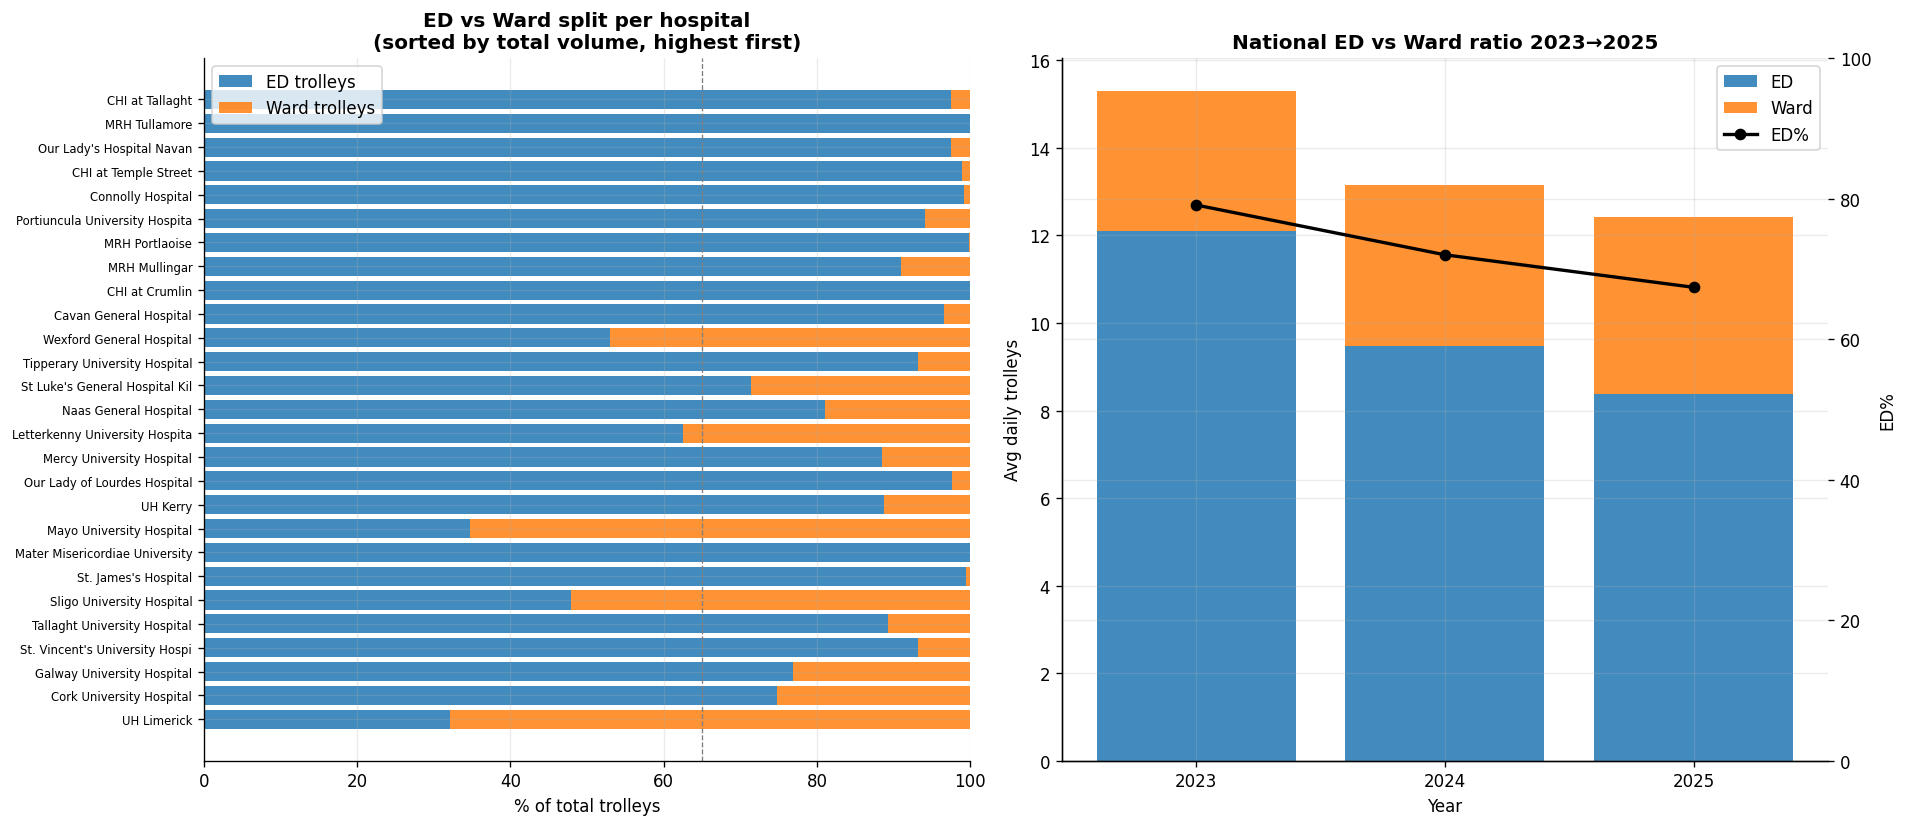

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: stacked bar per hospital
ax = axes[0]
y_pos = range(len(h3_avg))
ax.barh(y_pos, h3_avg['ed_pct'],   color=PALETTE[0], alpha=0.85, label='ED trolleys')
ax.barh(y_pos, h3_avg['ward_pct'], left=h3_avg['ed_pct'], color=PALETTE[1], alpha=0.85, label='Ward trolleys')
ax.set_yticks(y_pos)
ax.set_yticklabels([h[:30] for h in h3_avg['hospital']], fontsize=7)
ax.axvline(65, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('% of total trolleys')
ax.set_title('ED vs Ward split per hospital\n(sorted by total volume, highest first)', fontweight='bold')
ax.legend()

# Right: national ED/Ward ratio trend
ax2 = axes[1]
x = nat_split.index
ed_vals   = nat_split['ed_trolleys']
ward_vals = nat_split['ward_trolleys']
ax2.bar(x, ed_vals,   color=PALETTE[0], alpha=0.85, label='ED')
ax2.bar(x, ward_vals, bottom=ed_vals, color=PALETTE[1], alpha=0.85, label='Ward')
ax2b = ax2.twinx()
ax2b.plot(x, nat_split['ed_ratio'], color='black', marker='o', linewidth=2, label='ED%')
ax2b.set_ylabel('ED%')
ax2b.set_ylim(0, 100)
ax2b.spines['top'].set_visible(False)
ax2.set_xticks([2023, 2024, 2025])
ax2.set_xlabel('Year')
ax2.set_ylabel('Avg daily trolleys')
ax2.set_title('National ED vs Ward ratio 2023→2025', fontweight='bold')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.savefig('outputs/s3_ed_ward_split.png', bbox_inches='tight')
plt.show()

---
## Section 4 — Per-Capita Analysis: Population-Adjusted Pressure
Using `pop_region` (never used before).  
A region with fewer hospitals serving a large population may be underfunded relative to burden.

In [9]:
# Get regional daily total and population from daily_features
reg_feat = (
    feat[feat['total_trolleys'].notna() & feat['pop_region'].notna()]
    .groupby(['report_date', 'region'])
    .agg(total_trolleys=('total_trolleys', 'sum'), pop_region=('pop_region', 'first'))
    .reset_index()
)
reg_feat['trolleys_per_100k'] = reg_feat['total_trolleys'] / reg_feat['pop_region'] * 100_000
reg_feat['year'] = pd.to_datetime(reg_feat['report_date']).dt.year

# Average per-capita by region
pc_avg = reg_feat.groupby('region')['trolleys_per_100k'].mean().sort_values(ascending=False)
pc_abs = reg_feat.groupby('region')['total_trolleys'].mean().sort_values(ascending=False)

print('Trolleys per 100k population (all years avg):')
print(pc_avg.round(2).to_string())
print('\nAbsolute avg daily trolleys (for comparison):')
print(pc_abs.round(1).to_string())

# Rank shift between absolute and per-capita
rank_abs = pd.Series(range(1, len(pc_abs)+1), index=pc_abs.index)
rank_pc  = pd.Series(range(1, len(pc_avg)+1), index=pc_avg.index)
rank_df = pd.DataFrame({'rank_absolute': rank_abs, 'rank_per_capita': rank_pc,
                         'trolleys_per_100k': pc_avg.round(2),
                         'abs_trolleys': pc_abs.round(1)})
rank_df['rank_shift'] = rank_df['rank_absolute'] - rank_df['rank_per_capita']
print('\nRank shift (positive = higher burden than absolute rank suggests):')
print(rank_df)

Trolleys per 100k population (all years avg):
region
HSE West & North West      48.44
HSE Dublin & North East    47.53
HSE Dublin & Midlands      43.24
West / North-West           8.55
HSE South & South East      7.80
South / South-West          3.92
Dublin North East           1.02
Dublin Midlands             0.84

Absolute avg daily trolleys (for comparison):
region
HSE West & North West      76.7
HSE South & South East     45.6
HSE Dublin & Midlands      41.6
HSE Dublin & North East    38.8
South / South-West         22.9
West / North-West          18.5
Dublin North East          14.8
Dublin Midlands            12.2

Rank shift (positive = higher burden than absolute rank suggests):
                         rank_absolute  rank_per_capita  trolleys_per_100k  \
region                                                                       
Dublin Midlands                      8                8               0.84   
Dublin North East                    7                7               1

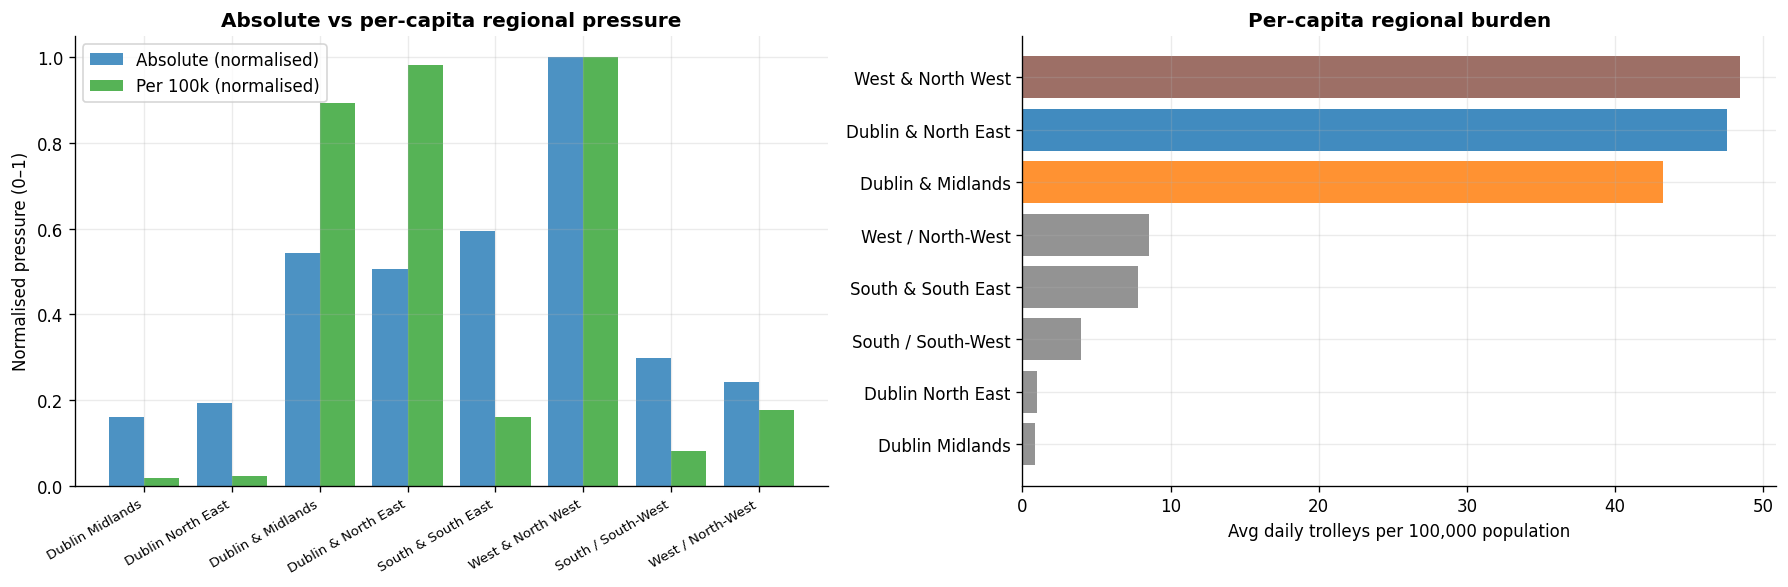

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: absolute vs per-capita comparison
ax = axes[0]
x = np.arange(len(rank_df))
labels = [r.replace('HSE ', '') for r in rank_df.index]

# Normalise both to 0–1 for visual comparison
abs_norm = rank_df['abs_trolleys'] / rank_df['abs_trolleys'].max()
pc_norm  = rank_df['trolleys_per_100k'] / rank_df['trolleys_per_100k'].max()

ax.bar(x - 0.2, abs_norm.values, 0.4, color=PALETTE[0], alpha=0.8, label='Absolute (normalised)')
ax.bar(x + 0.2, pc_norm.values,  0.4, color=PALETTE[2], alpha=0.8, label='Per 100k (normalised)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Normalised pressure (0–1)')
ax.set_title('Absolute vs per-capita regional pressure', fontweight='bold')
ax.legend()

# Right: trolleys per 100k bar (actual values)
ax2 = axes[1]
colors2 = [REGION_COLORS.get(r, 'grey') for r in pc_avg.index]
ax2.barh([r.replace('HSE ', '') for r in pc_avg.index], pc_avg.values, color=colors2, alpha=0.85)
ax2.set_xlabel('Avg daily trolleys per 100,000 population')
ax2.set_title('Per-capita regional burden', fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/s4_per_capita.png', bbox_inches='tight')
plt.show()

---
## Section 5 — Trolleys Per Bed: Relative Capacity Utilisation
Using `beds_total_ire` and `ref_bed_capacity_sector` (never used before).  
Has bed capacity kept pace with trolley growth?

In [11]:
# National yearly avg trolleys
nat_yearly = nat[nat['year'].isin([2023, 2024, 2025])].groupby('year')['total_trolleys'].mean()

# National bed count by year (from daily_features — same value per year)
beds_by_year = (
    feat[feat['beds_total_ire'].notna()]
    .assign(year=lambda d: d['report_date'].dt.year)
    .groupby('year')['beds_total_ire']
    .first()
)

# Combine
beds_df = pd.DataFrame({
    'nat_trolleys': nat_yearly,
    'beds': beds_by_year,
})
beds_df = beds_df.dropna()
beds_df['trolleys_per_bed'] = beds_df['nat_trolleys'] / beds_df['beds'] * 100
beds_df['yoy_trolley_chg']  = beds_df['nat_trolleys'].pct_change() * 100
beds_df['yoy_bed_chg']      = beds_df['beds'].pct_change() * 100

print('National beds vs trolleys:')
print(beds_df[['nat_trolleys', 'beds', 'trolleys_per_bed', 'yoy_trolley_chg', 'yoy_bed_chg']].round(1))

# Public vs private beds
print('\nBed capacity by sector:')
print(beds_sec.pivot(index='year', columns='sector', values='beds_total').fillna('–'))

National beds vs trolleys:
      nat_trolleys   beds  trolleys_per_bed  yoy_trolley_chg  yoy_bed_chg
year                                                                     
2023         333.0  15372               2.2              NaN          NaN
2024         296.3  15372               1.9            -11.0          0.0
2025         265.6  15372               1.7            -10.4          0.0

Bed capacity by sector:
sector  Privately owned hospitals  Publicly owned hospitals  Total hospitals
year                                                                        
2020                         1715                     12697            14412
2021                         1662                     12905            14567
2022                         1793                     13216            15009
2023                         1876                     13496            15372


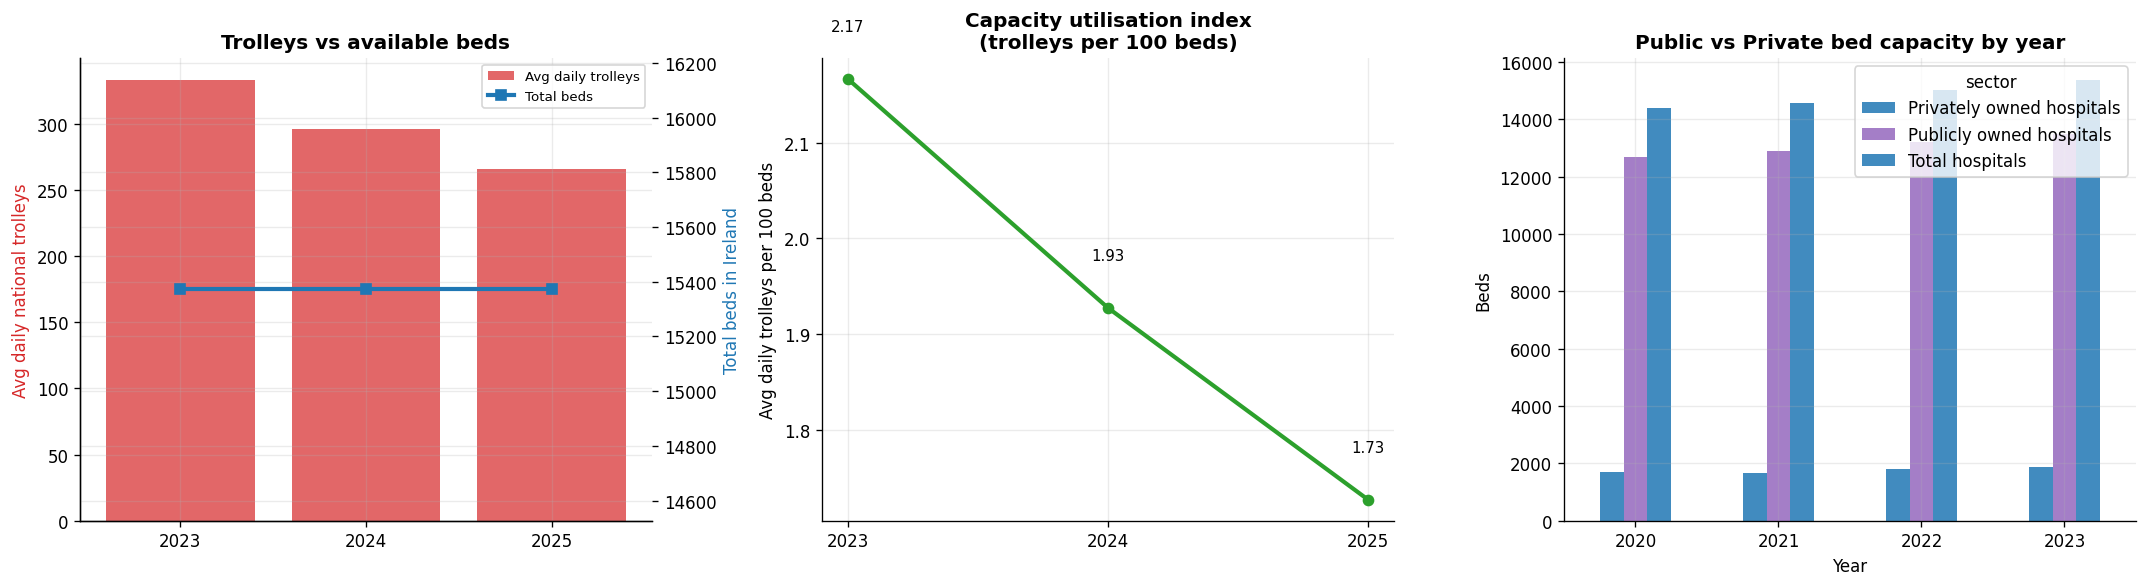

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

years = beds_df.index.tolist()

# Left: dual-axis — trolleys and beds
ax = axes[0]
ax2 = ax.twinx()
ax.bar(years, beds_df['nat_trolleys'], color=PALETTE[3], alpha=0.7, label='Avg daily trolleys')
ax2.plot(years, beds_df['beds'], color=PALETTE[0], marker='s', linewidth=2.5, label='Total beds')
ax.set_xticks(years)
ax.set_ylabel('Avg daily national trolleys', color=PALETTE[3])
ax2.set_ylabel('Total beds in Ireland', color=PALETTE[0])
ax2.spines['top'].set_visible(False)
ax.set_title('Trolleys vs available beds', fontweight='bold')
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, fontsize=8)

# Middle: trolleys per 100 beds
ax3 = axes[1]
ax3.plot(years, beds_df['trolleys_per_bed'], marker='o', color=PALETTE[2], linewidth=2.5)
for y, v in zip(years, beds_df['trolleys_per_bed']):
    ax3.text(y, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
ax3.set_xticks(years)
ax3.set_ylabel('Avg daily trolleys per 100 beds')
ax3.set_title('Capacity utilisation index\n(trolleys per 100 beds)', fontweight='bold')

# Right: public vs private beds
ax4 = axes[2]
if not beds_sec.empty:
    piv_sec = beds_sec.pivot(index='year', columns='sector', values='beds_total').fillna(0)
    piv_sec.plot(kind='bar', ax=ax4, color=[PALETTE[0], PALETTE[4]], alpha=0.85)
    ax4.set_title('Public vs Private bed capacity by year', fontweight='bold')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Beds')
    ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('outputs/s5_beds.png', bbox_inches='tight')
plt.show()

---
## Section 6 — Full Weather Signal: Beyond Temperature
Using `rhum`, `pres`, `tsun` (never used before) alongside the existing weather vars.  
Partial correlation controlling for seasonality (month), and interaction effects.

In [13]:
# National daily weather: use 'National Total' hospital in daily_features if it exists,
# otherwise aggregate hospital weather by taking a single hospital per day (weather is city-level)
wx_cols = ['tavg', 'tmin', 'tmax', 'prcp', 'rhum', 'pres', 'wspd', 'tsun']

# Average weather across all hospitals per day (same weather per city, so use first per date)
wx_nat = (
    feat.sort_values('report_date')
    .groupby('report_date')[wx_cols + ['total_trolleys', 'month']]
    .mean()
    .reset_index()
)
wx_nat = wx_nat.dropna(subset=['total_trolleys'])

# Raw Pearson correlations with total trolleys
raw_corr = wx_nat[wx_cols + ['total_trolleys']].corr()['total_trolleys'].drop('total_trolleys')
print('Raw correlations (weather → trolleys):')
print(raw_corr.sort_values().round(3).to_string())

# Partial correlation: remove month effect first via residuals
def partial_corr(df, x_col, y_col, control_col):
    """Pearson r of x,y after linearly removing effect of control_col from both."""
    sub = df[[x_col, y_col, control_col]].dropna()
    x_res = stats.linregress(sub[control_col], sub[x_col])
    y_res = stats.linregress(sub[control_col], sub[y_col])
    x_detrended = sub[x_col] - (x_res.slope * sub[control_col] + x_res.intercept)
    y_detrended = sub[y_col] - (y_res.slope * sub[control_col] + y_res.intercept)
    r, p = stats.pearsonr(x_detrended, y_detrended)
    return r, p

partial_results = {}
for col in wx_cols:
    if wx_nat[col].notna().sum() > 100:
        r, p = partial_corr(wx_nat, col, 'total_trolleys', 'month')
        partial_results[col] = {'partial_r': round(r, 3), 'p_value': round(p, 4)}

pcorr_df = pd.DataFrame(partial_results).T.sort_values('partial_r')
print('\nPartial correlations (controlling for month):')
print(pcorr_df.to_string())

Raw correlations (weather → trolleys):
tavg   -0.138
tmax   -0.128
tmin   -0.126
pres   -0.083
wspd    0.003
prcp    0.050
rhum      NaN
tsun      NaN

Partial correlations (controlling for month):
      partial_r  p_value
pres     -0.082   0.0047
tavg     -0.081   0.0052
tmax     -0.080   0.0062
tmin     -0.065   0.0258
wspd      0.001   0.9742
prcp      0.061   0.0352


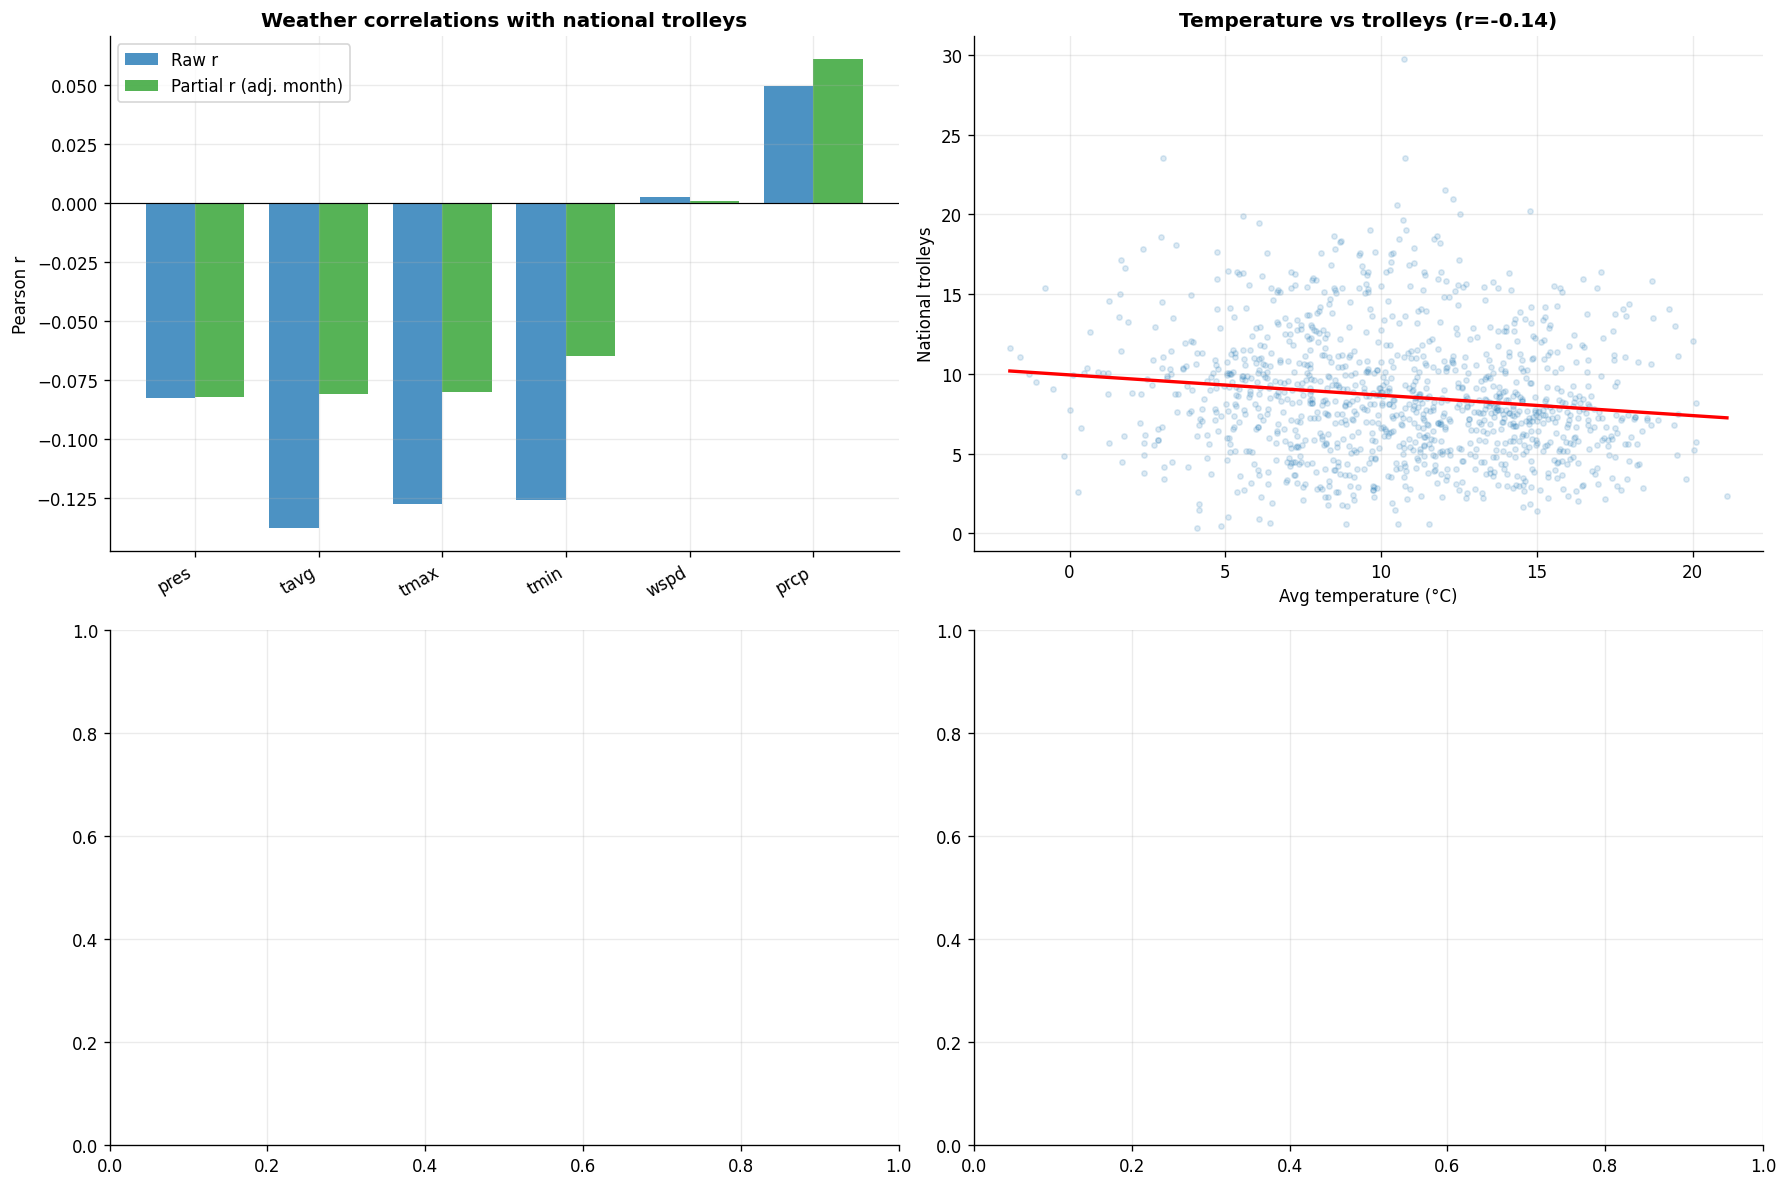

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top-left: raw vs partial correlation
ax = axes[0, 0]
if not pcorr_df.empty:
    x_idx = np.arange(len(pcorr_df))
    ax.bar(x_idx - 0.2, raw_corr[pcorr_df.index].values, 0.4, color=PALETTE[0], alpha=0.8, label='Raw r')
    ax.bar(x_idx + 0.2, pcorr_df['partial_r'].values, 0.4, color=PALETTE[2], alpha=0.8, label='Partial r (adj. month)')
    ax.set_xticks(x_idx)
    ax.set_xticklabels(pcorr_df.index, rotation=30, ha='right')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_ylabel('Pearson r')
    ax.set_title('Weather correlations with national trolleys', fontweight='bold')
    ax.legend()

# Top-right: temperature vs trolleys scatter
ax2 = axes[0, 1]
valid = wx_nat[['tavg', 'total_trolleys']].dropna()
ax2.scatter(valid['tavg'], valid['total_trolleys'], alpha=0.15, s=10, color=PALETTE[0])
m, b, r, p, _ = stats.linregress(valid['tavg'], valid['total_trolleys'])
x_line = np.linspace(valid['tavg'].min(), valid['tavg'].max(), 100)
ax2.plot(x_line, m * x_line + b, color='red', linewidth=2)
ax2.set_xlabel('Avg temperature (°C)')
ax2.set_ylabel('National trolleys')
ax2.set_title(f'Temperature vs trolleys (r={r:.2f})', fontweight='bold')

# Bottom-left: humidity vs trolleys (new variable)
ax3 = axes[1, 0]
valid2 = wx_nat[['rhum', 'total_trolleys']].dropna()
if len(valid2) > 50:
    ax3.scatter(valid2['rhum'], valid2['total_trolleys'], alpha=0.15, s=10, color=PALETTE[4])
    m2, b2, r2, p2, _ = stats.linregress(valid2['rhum'], valid2['total_trolleys'])
    x2 = np.linspace(valid2['rhum'].min(), valid2['rhum'].max(), 100)
    ax3.plot(x2, m2 * x2 + b2, color='red', linewidth=2)
    ax3.set_xlabel('Relative humidity (%)')
    ax3.set_ylabel('National trolleys')
    ax3.set_title(f'Humidity vs trolleys (r={r2:.2f}) — new signal', fontweight='bold')

# Bottom-right: sunshine hours vs trolleys (new variable)
ax4 = axes[1, 1]
valid3 = wx_nat[['tsun', 'total_trolleys']].dropna()
if len(valid3) > 50:
    ax4.scatter(valid3['tsun'], valid3['total_trolleys'], alpha=0.15, s=10, color=PALETTE[5])
    m3, b3, r3, p3, _ = stats.linregress(valid3['tsun'], valid3['total_trolleys'])
    x3 = np.linspace(valid3['tsun'].min(), valid3['tsun'].max(), 100)
    ax4.plot(x3, m3 * x3 + b3, color='red', linewidth=2)
    ax4.set_xlabel('Sunshine hours')
    ax4.set_ylabel('National trolleys')
    ax4.set_title(f'Sunshine vs trolleys (r={r3:.2f}) — new signal', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/s6_weather.png', bbox_inches='tight')
plt.show()

---
## Section 7 — Worst Days: Anatomy of a Crisis
Top 20 worst national days — which hospitals drove each crisis?  
Heatmap: hospitals × worst days.

In [15]:
# Top 20 worst national days
top20 = nat.nlargest(20, 'total_trolleys')[['report_date', 'total_trolleys']].reset_index(drop=True)
top20_dates = top20['report_date'].tolist()

print('Top 20 worst days:')
print(top20.to_string(index=False))

# Hospital breakdown on those days
worst_hosp = hosp[hosp['report_date'].isin(top20_dates)][['report_date', 'hospital', 'total_trolleys']].copy()

# Pivot: rows = hospitals, cols = worst days
pivot = worst_hosp.pivot_table(index='hospital', columns='report_date', values='total_trolleys', aggfunc='sum')
pivot.columns = [str(d.date()) for d in pivot.columns]

# Consistency score: how often does each hospital appear in top 5 contributors
consistency = {}
for col in pivot.columns:
    top5 = pivot[col].nlargest(5).index.tolist()
    for h in top5:
        consistency[h] = consistency.get(h, 0) + 1

cons_df = pd.Series(consistency).sort_values(ascending=False).head(10)
print('\nMost consistent top-5 contributors on worst days:')
print(cons_df.to_string())

Top 20 worst days:
report_date  total_trolleys
 2023-01-03             804
 2023-01-04             645
 2023-01-02             624
 2025-02-04             617
 2025-02-05             588
 2023-05-02             576
 2023-12-11             576
 2023-05-03             564
 2025-01-28             551
 2024-02-07             550
 2023-03-28             549
 2023-05-09             548
 2023-03-27             541
 2023-12-13             537
 2023-03-21             534
 2025-01-06             534
 2023-05-08             533
 2026-01-13             531
 2023-12-12             525
 2023-02-21             523

Most consistent top-5 contributors on worst days:
UH Limerick                                20
St. Vincent's University Hospital          15
Cork University Hospital                   15
Mater Misericordiae University Hospital    10
Tallaght University Hospital                9
Galway University Hospital                  9
St. James's Hospital                        9
Sligo University Hos

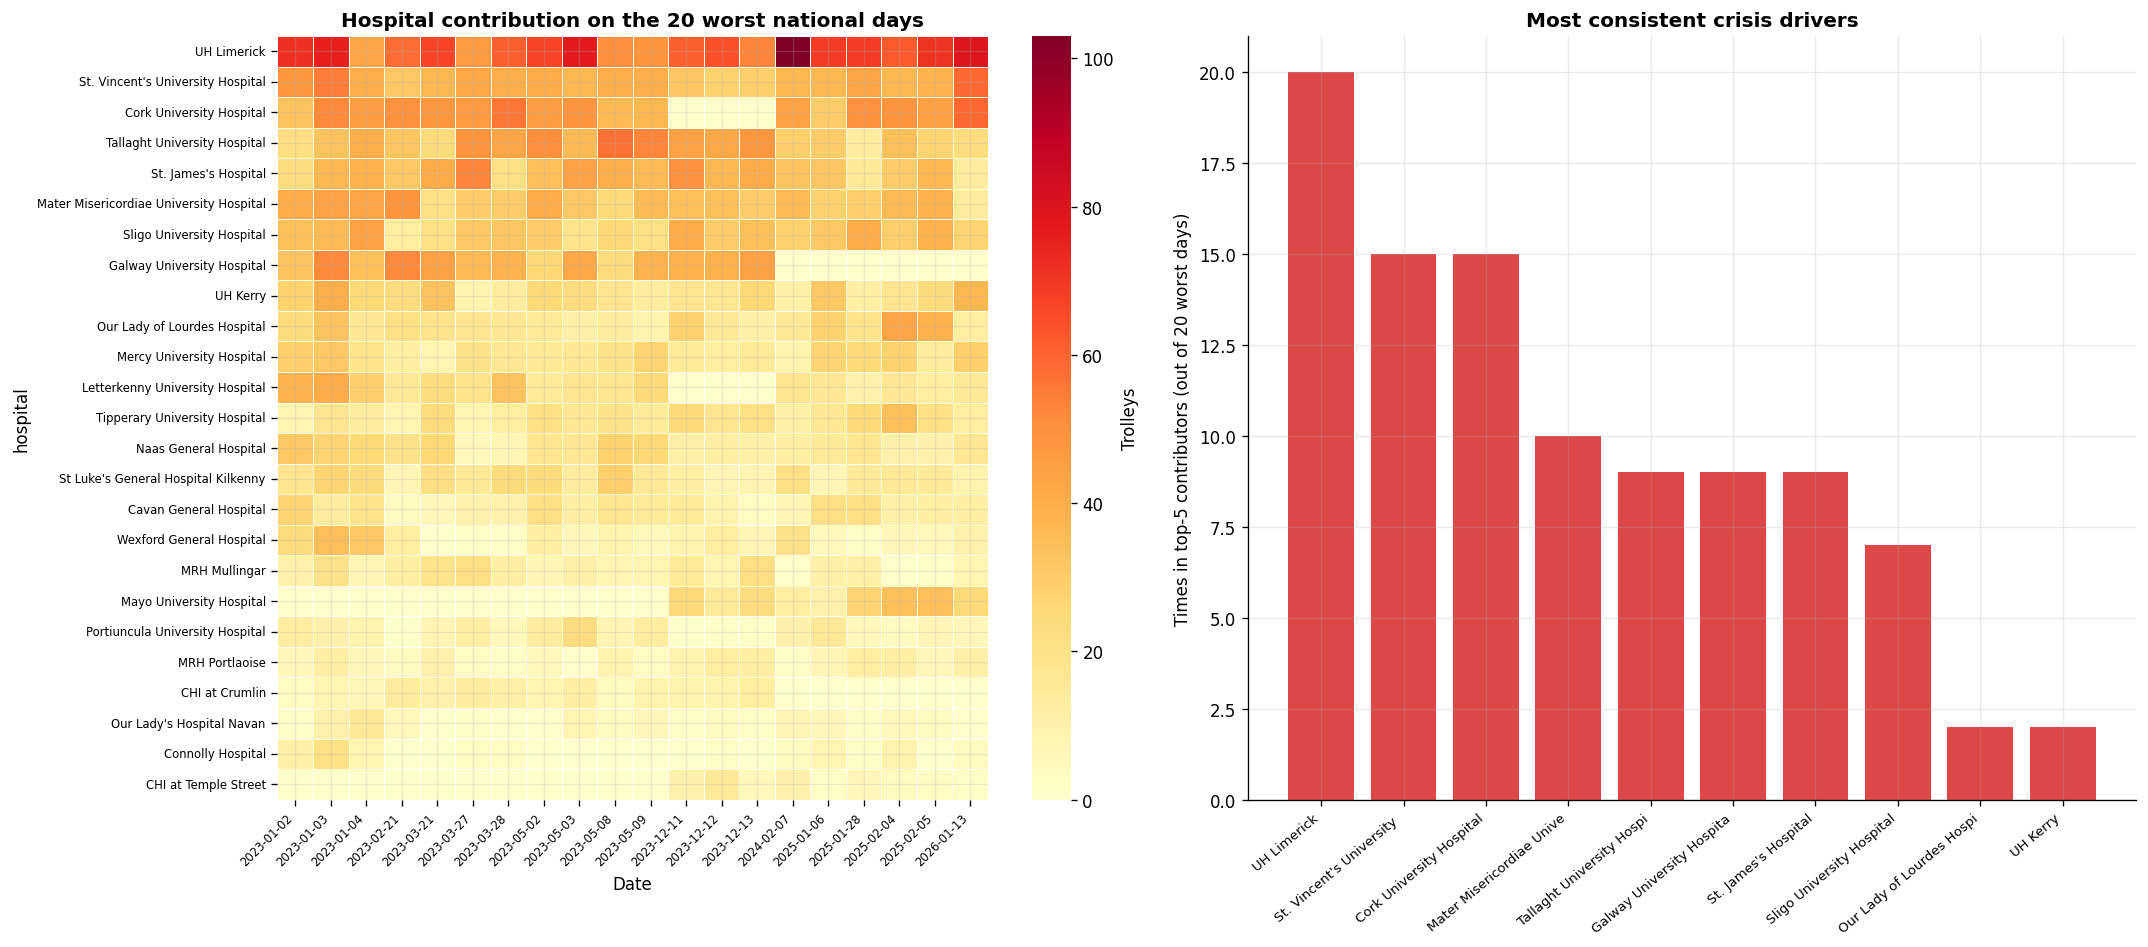

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: heatmap
ax = axes[0]
# Sort hospitals by total contribution on worst days
pivot_sorted = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
sns.heatmap(
    pivot_sorted.fillna(0).head(25),
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.3,
    cbar_kws={'label': 'Trolleys'},
    yticklabels=True,
)
ax.set_title('Hospital contribution on the 20 worst national days', fontweight='bold')
ax.set_xlabel('Date')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

# Right: consistency score bar
ax2 = axes[1]
ax2.bar(range(len(cons_df)), cons_df.values, color=PALETTE[3], alpha=0.85)
ax2.set_xticks(range(len(cons_df)))
ax2.set_xticklabels([h[:25] for h in cons_df.index], rotation=40, ha='right', fontsize=8)
ax2.set_ylabel('Times in top-5 contributors (out of 20 worst days)')
ax2.set_title('Most consistent crisis drivers', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/s7_worst_days.png', bbox_inches='tight')
plt.show()

---
## Section 8 — Regional Inequality: Converging or Diverging?
Monthly regional averages 2023–2026. Is the gap between best and worst region growing?

In [17]:
# Monthly regional totals (sum across hospitals in region)
hosp['ym'] = hosp['report_date'].dt.to_period('M')
reg_monthly = (
    hosp.groupby(['ym', 'region'])['total_trolleys']
    .sum()
    .reset_index()
)
reg_monthly['date'] = reg_monthly['ym'].dt.to_timestamp()

# Inequality index per month: max/min ratio and range
inequality = (
    reg_monthly.groupby('ym')['total_trolleys']
    .agg(max_val='max', min_val='min', range_val=lambda x: x.max() - x.min())
    .reset_index()
)
inequality['max_min_ratio'] = inequality['max_val'] / inequality['min_val']
inequality['date'] = inequality['ym'].dt.to_timestamp()

# Annual inequality
reg_yearly = (
    hosp[hosp['year'].isin([2023, 2024, 2025])]
    .groupby(['year', 'region'])['total_trolleys']
    .sum()
    .reset_index()
)
annual_ineq = reg_yearly.groupby('year').apply(
    lambda g: g['total_trolleys'].max() / g['total_trolleys'].min()
).rename('max_min_ratio')
print('Annual inequality index (max/min ratio):')
print(annual_ineq.round(2).to_string())

Annual inequality index (max/min ratio):
year
2023    63.90
2024     1.52
2025     1.59


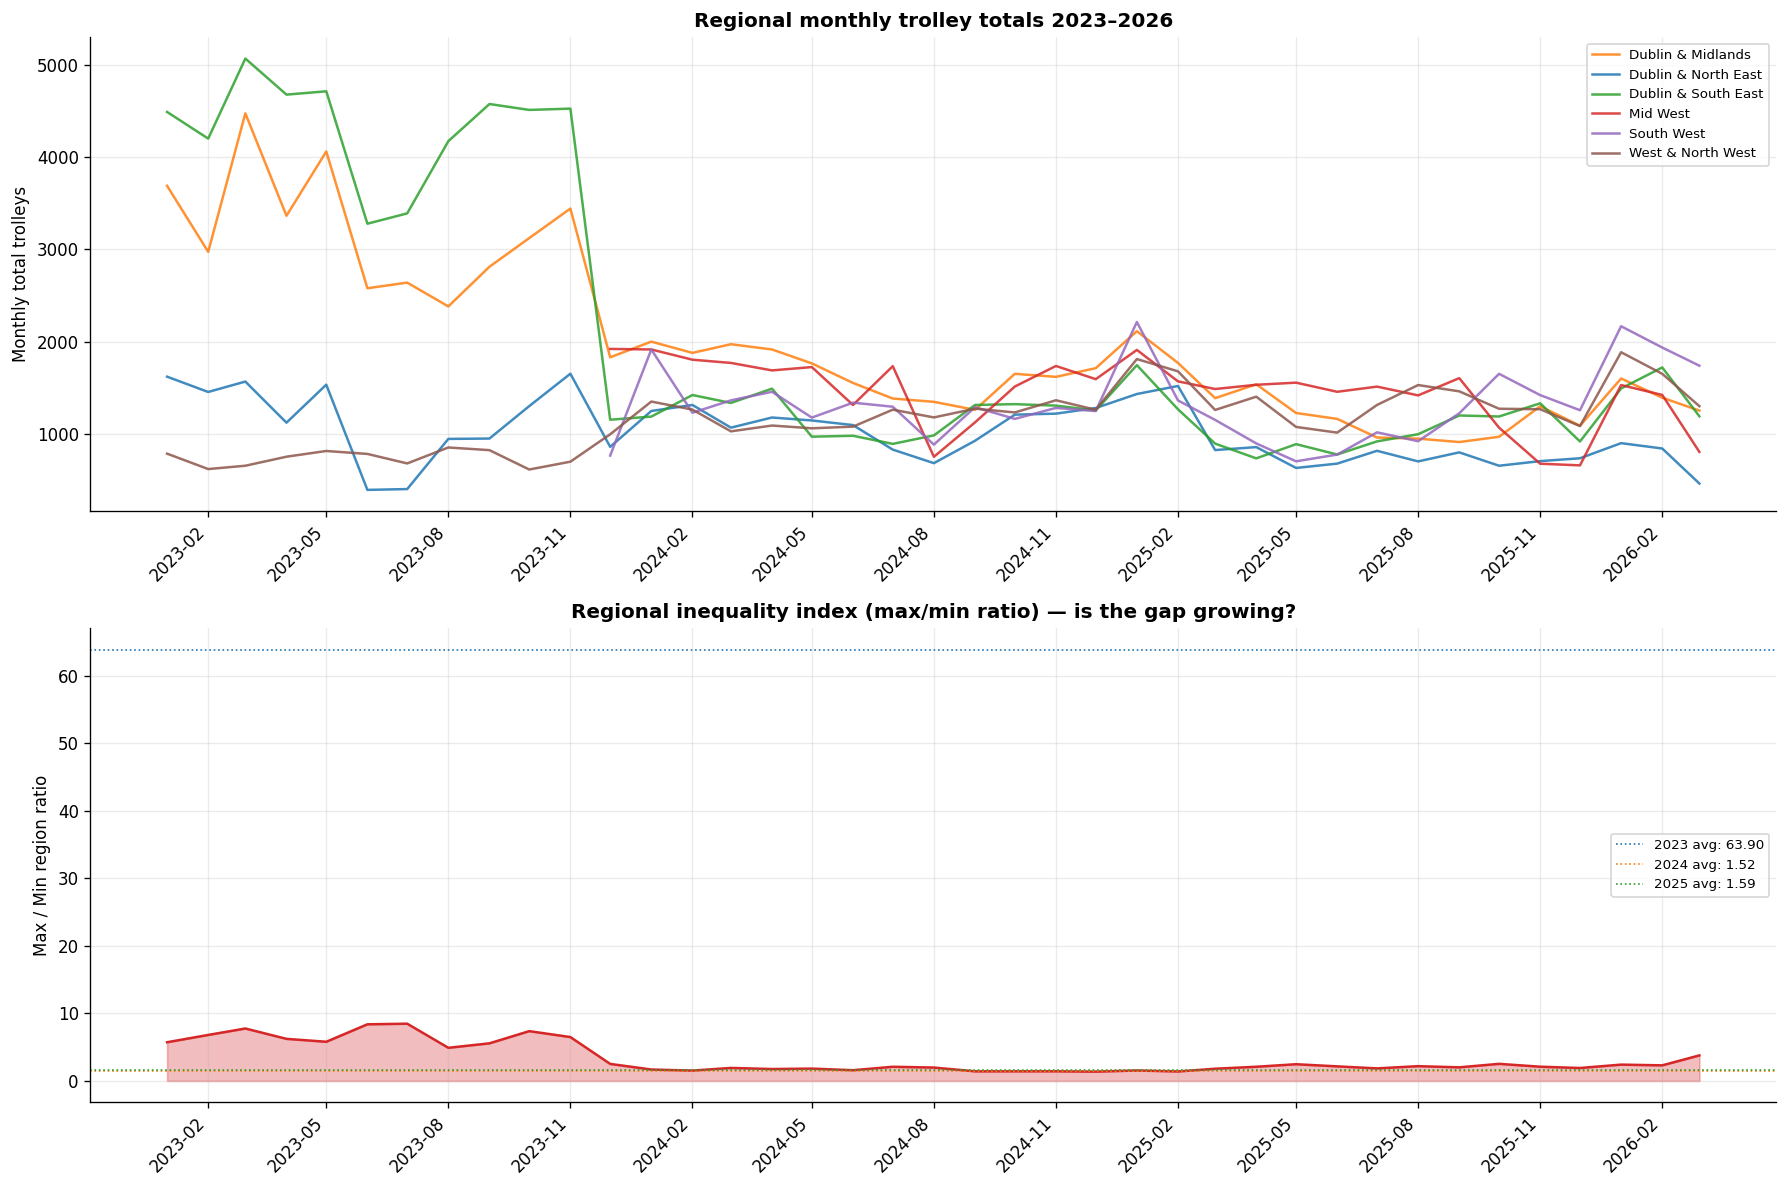

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Top: regional monthly trend lines
ax = axes[0]
for region, grp in reg_monthly.groupby('region'):
    grp_sorted = grp.sort_values('date')
    c = REGION_COLORS.get(region, 'grey')
    ax.plot(grp_sorted['date'], grp_sorted['total_trolleys'], color=c, linewidth=1.5,
            label=region.replace('HSE ', ''), alpha=0.85)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_ylabel('Monthly total trolleys')
ax.set_title('Regional monthly trolley totals 2023–2026', fontweight='bold')
ax.legend(fontsize=8)

# Bottom: inequality index over time
ax2 = axes[1]
ineq_sorted = inequality.sort_values('date')
ax2.fill_between(ineq_sorted['date'], ineq_sorted['max_min_ratio'], alpha=0.3, color=PALETTE[3])
ax2.plot(ineq_sorted['date'], ineq_sorted['max_min_ratio'], color=PALETTE[3], linewidth=1.5)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.set_ylabel('Max / Min region ratio')
ax2.set_title('Regional inequality index (max/min ratio) — is the gap growing?', fontweight='bold')

# Mark annual averages
for yr, val in annual_ineq.items():
    ax2.axhline(val, color=PALETTE[yr - 2023], linestyle=':', linewidth=1,
                label=f'{yr} avg: {val:.2f}')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/s8_regional_inequality.png', bbox_inches='tight')
plt.show()

---
## Section 9 — Volatility: Predictable vs Chaotic Hospitals
Mean trolleys vs coefficient of variation (CV = std/mean) per hospital.  
High CV + high mean = hardest to plan for.

In [19]:

vol = (
    hosp.groupby('hospital')['total_trolleys']
    .agg(mean='mean', std='std', count='count')
    .reset_index()
)
vol['cv'] = vol['std'] / vol['mean']
vol['region'] = vol['hospital'].map(region_map)
vol = vol[vol['count'] > 30].copy()  # exclude sparse hospitals

med_mean = vol['mean'].median()
med_cv   = vol['cv'].median()

def quadrant_label(row):
    if row['mean'] >= med_mean and row['cv'] >= med_cv: return 'High pressure + Chaotic'
    if row['mean'] >= med_mean and row['cv'] <  med_cv: return 'High pressure + Stable'
    if row['mean'] <  med_mean and row['cv'] >= med_cv: return 'Low pressure + Chaotic'
    return 'Low pressure + Stable'

vol['quadrant'] = vol.apply(quadrant_label, axis=1)
print(vol[['hospital', 'mean', 'cv', 'quadrant']].sort_values('cv', ascending=False).to_string(index=False))

print('\nMost chaotic high-pressure hospitals:')
print(vol[vol['quadrant'] == 'High pressure + Chaotic'][['hospital', 'mean', 'cv']]
      .sort_values('cv', ascending=False).to_string(index=False))


                                    hospital      mean       cv                quadrant
                               MRH Tullamore  0.052542 9.580360  Low pressure + Chaotic
                           Connolly Hospital  1.104237 2.463163  Low pressure + Chaotic
                   Our Lady's Hospital Navan  1.238983 1.792412  Low pressure + Chaotic
                             CHI at Tallaght  0.945471 1.633190  Low pressure + Chaotic
             Portiuncula University Hospital  3.233898 1.207818  Low pressure + Chaotic
                        CHI at Temple Street  2.557920 1.060214  Low pressure + Chaotic
         St Luke's General Hospital Kilkenny  6.524576 1.018245 High pressure + Chaotic
                               MRH Mullingar  5.086441 0.927267 High pressure + Chaotic
                      Cavan General Hospital  5.526271 0.912216 High pressure + Chaotic
                              CHI at Crumlin  4.862069 0.888116 High pressure + Chaotic
                              MR

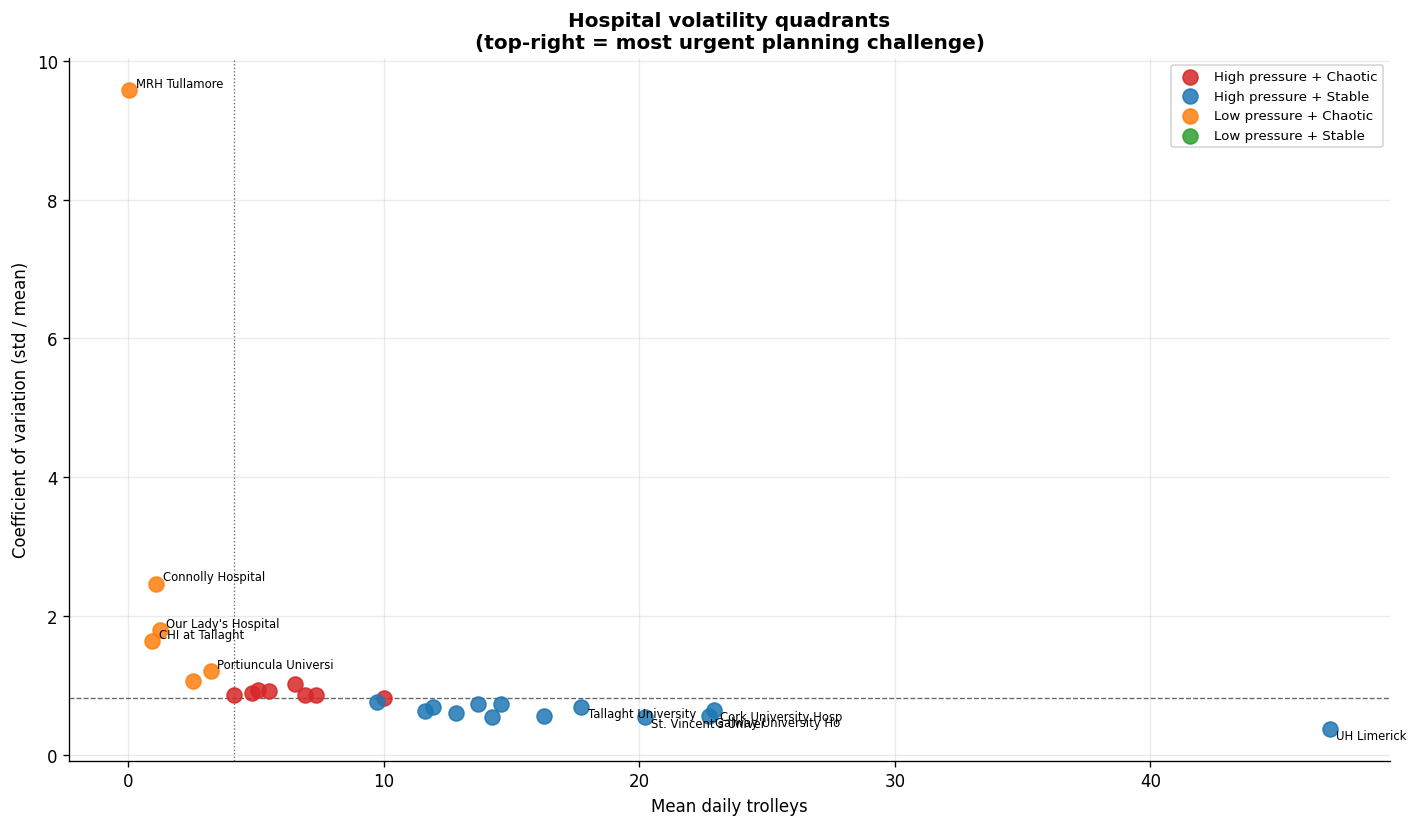

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))

quad_colors = {
    'High pressure + Chaotic': PALETTE[3],
    'High pressure + Stable' : PALETTE[0],
    'Low pressure + Chaotic' : PALETTE[1],
    'Low pressure + Stable'  : PALETTE[2],
}

for quad, grp in vol.groupby('quadrant'):
    ax.scatter(grp['mean'], grp['cv'], color=quad_colors[quad],
               s=80, alpha=0.85, label=quad, zorder=3)

ax.axhline(med_cv,   color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(med_mean, color='black', linestyle=':',  linewidth=0.8, alpha=0.6)

# Annotate extreme points
for _, r in vol.nlargest(5, 'cv').iterrows():
    ax.annotate(r['hospital'][:20], (r['mean'], r['cv']),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
for _, r in vol.nlargest(5, 'mean').iterrows():
    ax.annotate(r['hospital'][:20], (r['mean'], r['cv']),
                fontsize=7, xytext=(4, -6), textcoords='offset points')

ax.set_xlabel('Mean daily trolleys')
ax.set_ylabel('Coefficient of variation (std / mean)')
ax.set_title('Hospital volatility quadrants\n(top-right = most urgent planning challenge)', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/s9_volatility.png', bbox_inches='tight')
plt.show()

---
## Section 10 — Data Quality Audit
Which hospitals report every day vs have gaps?  
Are gaps random (system outages) or patterned (weekends, holidays)?  
Models trained on incomplete data may be systematically biased.

In [21]:
# Expected date range
date_range = pd.date_range(hosp['report_date'].min(), hosp['report_date'].max(), freq='D')
all_hospitals = hosp['hospital'].unique()

# Actual reported dates per hospital
reported = hosp.groupby('hospital')['report_date'].apply(set)

# Missing count per hospital
missing = {h: len(date_range) - len(reported[h]) for h in all_hospitals if h in reported}
missing_df = pd.Series(missing).sort_values(ascending=False)
pct_missing = missing_df / len(date_range) * 100

print(f'Total expected dates: {len(date_range)}')
print('\nMissing report days per hospital (top 10):')
print(pd.DataFrame({'missing_days': missing_df.head(10), 'pct': pct_missing.head(10).round(1)}).to_string())

# Are gaps patterned? Check weekday distribution of missing dates
all_missing_dates = []
for h, rep_dates in reported.items():
    for d in date_range:
        if d not in rep_dates:
            all_missing_dates.append(d)

if all_missing_dates:
    miss_dow = pd.Series([d.dayofweek for d in all_missing_dates]).value_counts().sort_index()
    miss_dow.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    print('\nMissing report weekday distribution (0=Mon):')
    print(miss_dow.to_string())

# Monthly coverage heatmap data
hosp['ym_str'] = hosp['report_date'].dt.strftime('%Y-%m')
months = sorted(hosp['ym_str'].unique())
days_per_month = hosp['report_date'].dt.to_period('M').value_counts().to_dict()

cov_data = {}
for h in all_hospitals:
    h_months = hosp[hosp['hospital'] == h].groupby('ym_str')['report_date'].count()
    cov_data[h] = h_months

cov_df = pd.DataFrame(cov_data).T.reindex(columns=months).fillna(0)

Total expected dates: 1180

Missing report days per hospital (top 10):
                                  missing_days   pct
Ennis Hospital                            1137  96.4
National Rehabilitation Hospital          1137  96.4
Bantry General Hospital                   1137  96.4
Galway University Hospital                 803  68.1
CHI at Crumlin                             803  68.1
Nenagh Hospital                            377  31.9
Louth County Hospital                      377  31.9
St. Columcille's Hospital                  377  31.9
UH Waterford                               334  28.3
CHI at Temple Street                       334  28.3

Missing report weekday distribution (0=Mon):
Mon    1379
Tue    1379
Wed    1379
Thu    1374
Fri    1364
Sat    1363
Sun    1379


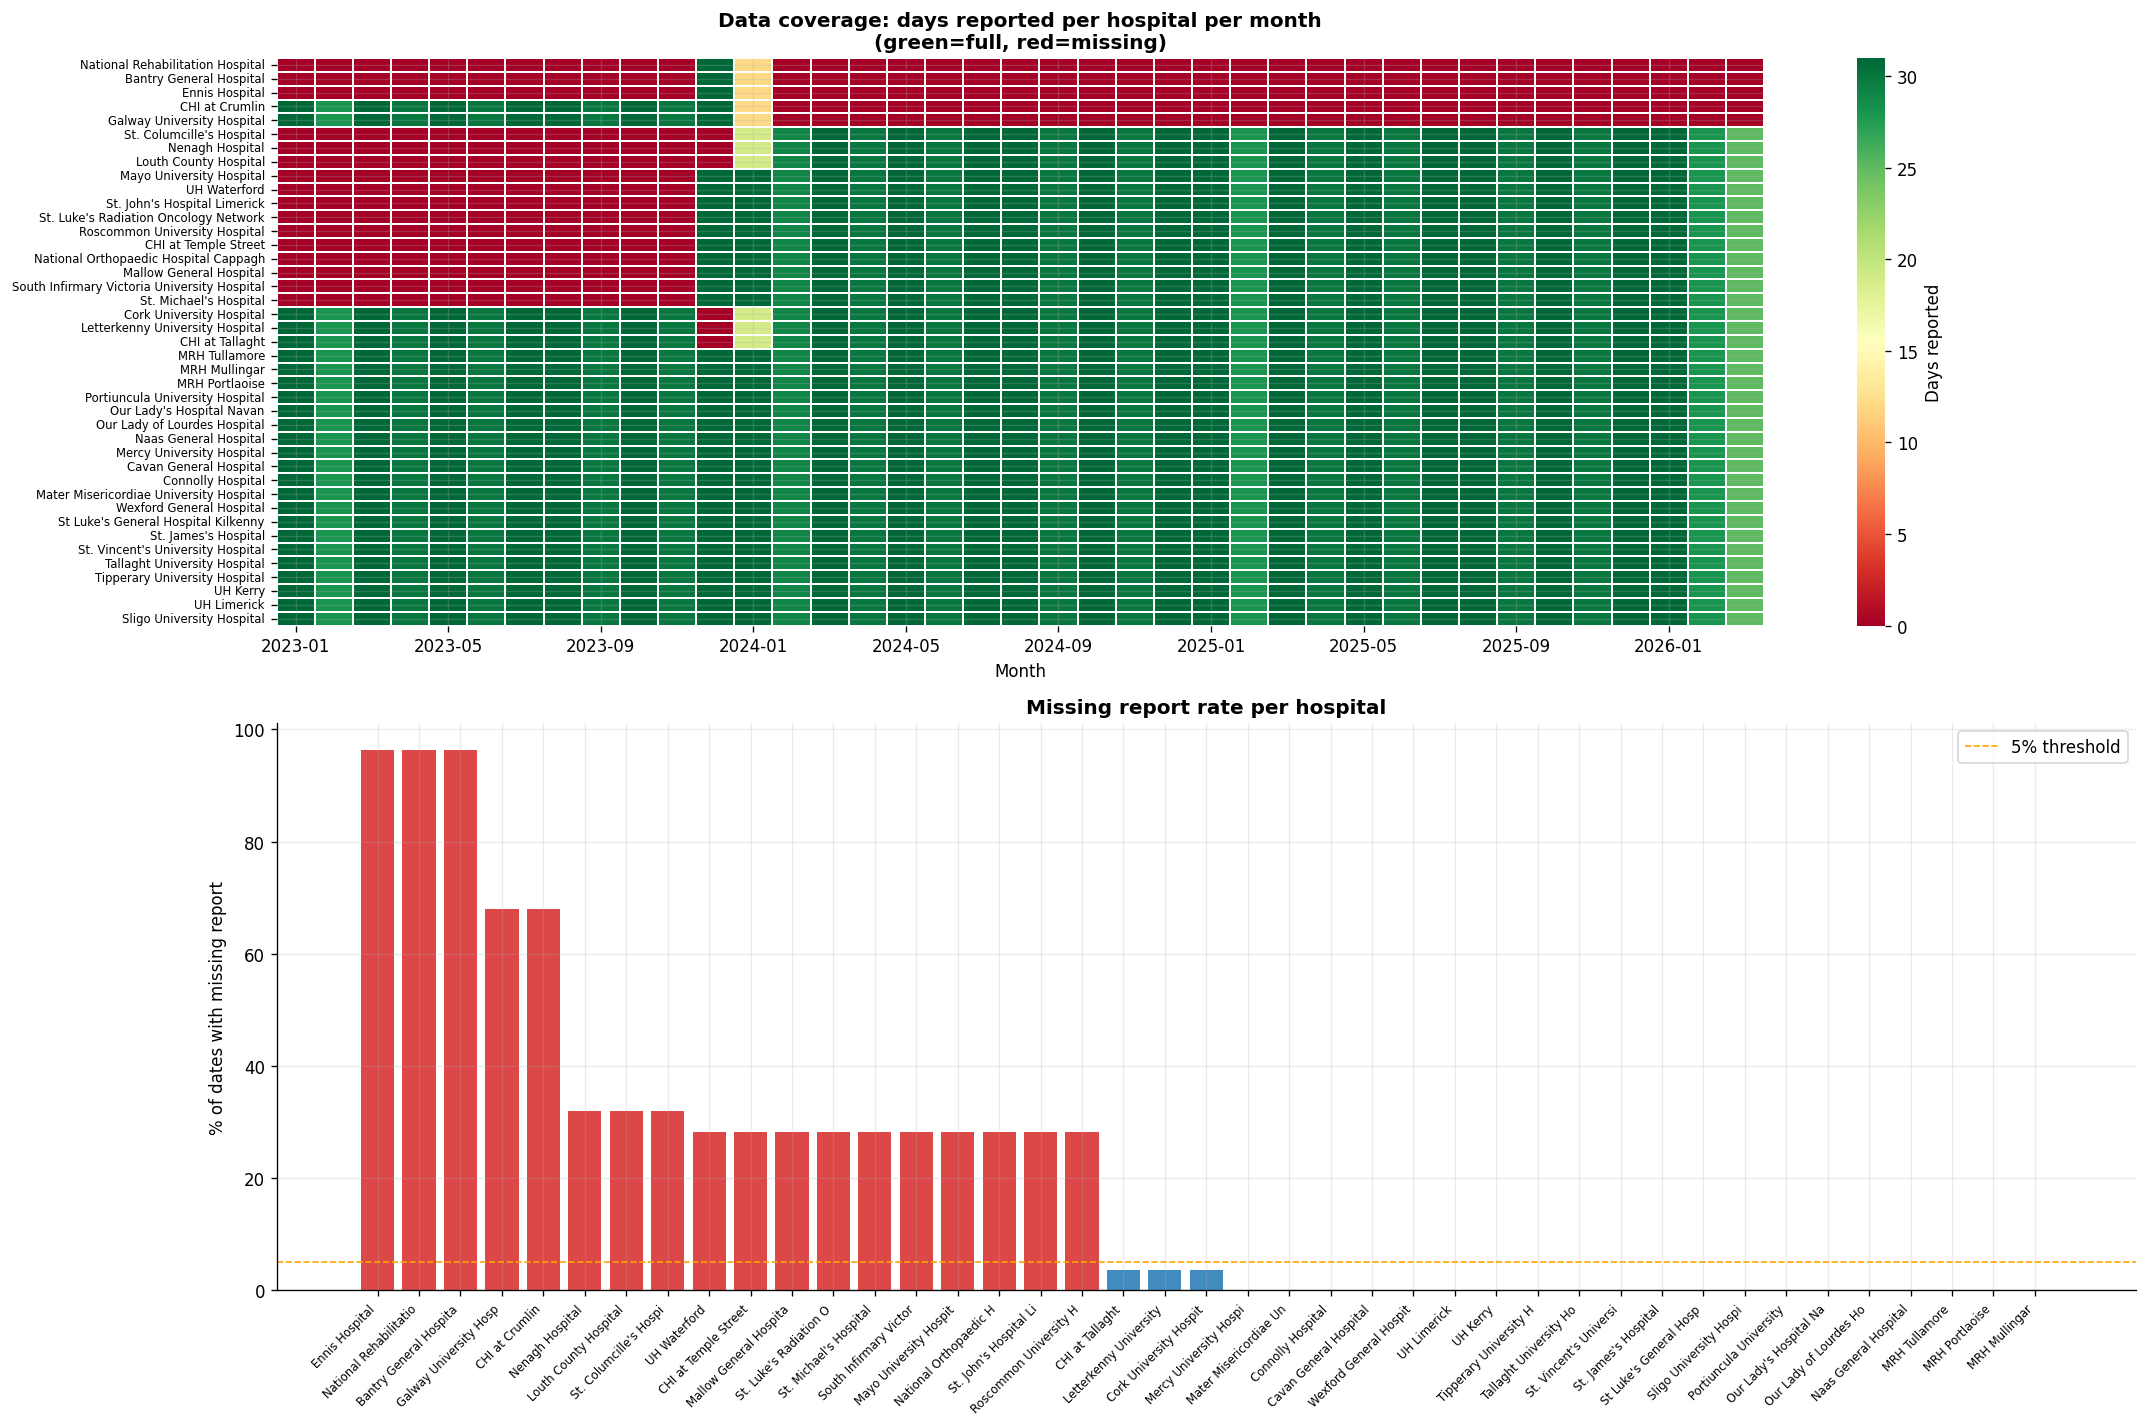

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Top: coverage heatmap (hospital × month)
ax = axes[0]
# Sort hospitals by total missing
cov_sorted = cov_df.loc[cov_df.sum(axis=1).sort_values().index]
sns.heatmap(
    cov_sorted,
    ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=31,
    linewidths=0.1,
    cbar_kws={'label': 'Days reported'},
    yticklabels=True,
    xticklabels=4,
)
ax.set_title('Data coverage: days reported per hospital per month\n(green=full, red=missing)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

# Bottom: missing days per hospital bar + weekday pattern inset
ax2 = axes[1]
bars = ax2.bar(range(len(pct_missing)), pct_missing.values,
               color=[PALETTE[3] if v > 5 else PALETTE[0] for v in pct_missing.values], alpha=0.85)
ax2.set_xticks(range(len(pct_missing)))
ax2.set_xticklabels([h[:22] for h in pct_missing.index], rotation=45, ha='right', fontsize=7)
ax2.set_ylabel('% of dates with missing report')
ax2.set_title('Missing report rate per hospital', fontweight='bold')
ax2.axhline(5, color='orange', linestyle='--', linewidth=1, label='5% threshold')
ax2.legend()

plt.tight_layout()
plt.savefig('outputs/s10_data_quality.png', bbox_inches='tight')
plt.show()

---
## Section 11 — Surge Capacity: When Is Extra Capacity Activated?
Using `surge_capacity` (recovered from blobs).  
Does surge capacity activation correlate with trolley counts? Does it help?

In [23]:
surge_nat = nat[nat['surge_capacity'].notna() & nat['total_trolleys'].notna()].copy()
surge_nat['surge_pct_beds'] = surge_nat['surge_capacity'] / surge_nat['total_trolleys'] * 100

r_surge, p_surge = stats.pearsonr(surge_nat['surge_capacity'], surge_nat['total_trolleys'])
print(f'Surge capacity ↔ national trolleys: r={r_surge:.3f}, p={p_surge:.4f}')

# Is surge correlated with next-day relief?
surge_nat_s = surge_nat.sort_values('report_date').copy()
surge_nat_s['next_day_trolleys'] = surge_nat_s['total_trolleys'].shift(-1)
surge_nat_s['trolley_change']    = surge_nat_s['next_day_trolleys'] - surge_nat_s['total_trolleys']

# High surge days vs low surge days
threshold = surge_nat_s['surge_capacity'].median()
high_surge = surge_nat_s[surge_nat_s['surge_capacity'] > threshold]
low_surge  = surge_nat_s[surge_nat_s['surge_capacity'] <= threshold]

print(f'\nNext-day trolley change:')
print(f'  High surge days (>{threshold:.0f}): {high_surge["trolley_change"].mean():+.1f} avg')
print(f'  Low surge days  (≤{threshold:.0f}): {low_surge["trolley_change"].mean():+.1f} avg')

# Seasonal pattern
surge_monthly = surge_nat.groupby('month')['surge_capacity'].mean()
print('\nAvg surge capacity by month:')
print(surge_monthly.round(0).to_string())

Surge capacity ↔ national trolleys: r=0.609, p=0.0000

Next-day trolley change:
  High surge days (>322): -17.4 avg
  Low surge days  (≤322): +17.3 avg

Avg surge capacity by month:
month
1     480.0
2     458.0
3     386.0
4     325.0
5     300.0
6     275.0
7     265.0
8     255.0
9     281.0
10    320.0
11    354.0
12    321.0


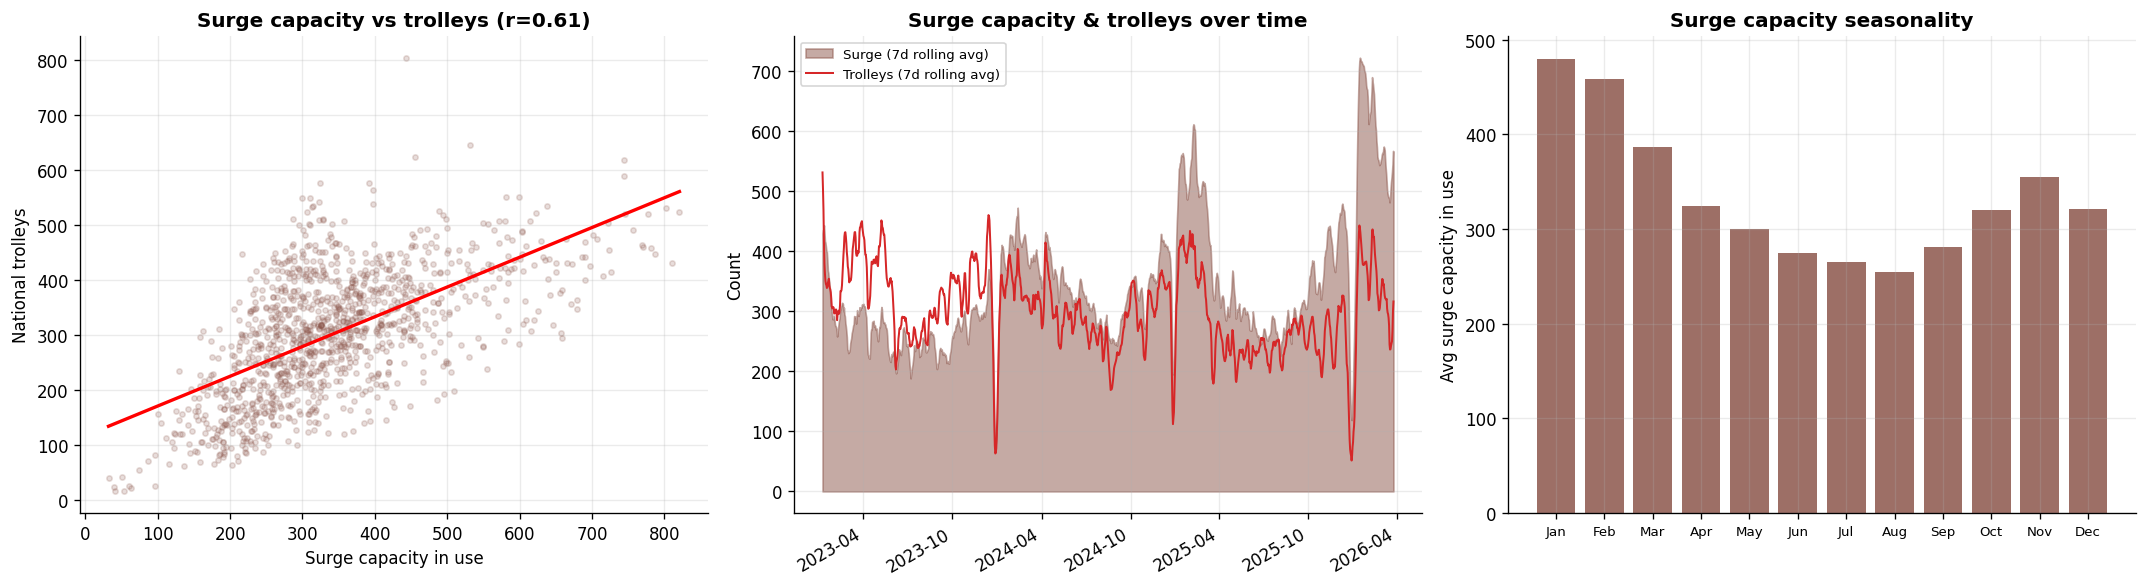

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: surge vs trolleys scatter
ax = axes[0]
ax.scatter(surge_nat['surge_capacity'], surge_nat['total_trolleys'],
           alpha=0.2, s=10, color=PALETTE[5])
m, b, _, _, _ = stats.linregress(surge_nat['surge_capacity'], surge_nat['total_trolleys'])
x = np.linspace(surge_nat['surge_capacity'].min(), surge_nat['surge_capacity'].max(), 100)
ax.plot(x, m * x + b, color='red', linewidth=2)
ax.set_xlabel('Surge capacity in use')
ax.set_ylabel('National trolleys')
ax.set_title(f'Surge capacity vs trolleys (r={r_surge:.2f})', fontweight='bold')

# Middle: surge over time (rolling 7-day)
ax2 = axes[1]
surge_ts = surge_nat.set_index('report_date').sort_index()
ax2.fill_between(surge_ts.index, surge_ts['surge_capacity'].rolling(7).mean(),
                 alpha=0.5, color=PALETTE[5], label='Surge (7d rolling avg)')
ax2.plot(surge_ts.index, surge_ts['total_trolleys'].rolling(7).mean(),
         color=PALETTE[3], linewidth=1.2, label='Trolleys (7d rolling avg)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.set_ylabel('Count')
ax2.set_title('Surge capacity & trolleys over time', fontweight='bold')
ax2.legend(fontsize=8)

# Right: monthly seasonality of surge
ax3 = axes[2]
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax3.bar(range(1, 13), [surge_monthly.get(m, 0) for m in range(1, 13)],
        color=PALETTE[5], alpha=0.85)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(month_names, fontsize=8)
ax3.set_ylabel('Avg surge capacity in use')
ax3.set_title('Surge capacity seasonality', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/s11_surge_capacity.png', bbox_inches='tight')
plt.show()

---
## Section 12 — Delayed Transfers of Care: Bed Block
Using `delayed_transfers` (recovered from blobs).  
Delayed transfers = patients medically fit but unable to leave due to social care failures.  
This is the primary driver of ward trolleys (bed block).

In [25]:
dtoc = nat[nat['delayed_transfers'].notna() & nat['total_trolleys'].notna()].copy()

# Correlation with ward trolleys (not total) — use hospital-level ward data joined with national delayed
ward_nat = hosp[hosp['ward_trolleys'].notna()].groupby('report_date')['ward_trolleys'].sum().reset_index()
ward_nat.columns = ['report_date', 'ward_total']
ward_nat['report_date'] = pd.to_datetime(ward_nat['report_date'])
dtoc_merged = dtoc.merge(ward_nat, on='report_date', how='inner')

r_dtoc_total, _ = stats.pearsonr(dtoc_merged['delayed_transfers'], dtoc_merged['total_trolleys'])
r_dtoc_ward,  _ = stats.pearsonr(dtoc_merged['delayed_transfers'], dtoc_merged['ward_total'])

print(f'Delayed transfers ↔ total trolleys: r={r_dtoc_total:.3f}')
print(f'Delayed transfers ↔ ward trolleys:  r={r_dtoc_ward:.3f}  ← bed block signal')

# Trend
dtoc['year'] = dtoc['report_date'].dt.year
dtoc_yearly = dtoc[dtoc['year'].isin([2023, 2024, 2025])].groupby('year')['delayed_transfers'].mean()
print('\nAvg delayed transfers by year:')
print(dtoc_yearly.round(0).to_string())

# Seasonal pattern
dtoc['month'] = dtoc['report_date'].dt.month
dtoc_monthly = dtoc.groupby('month')['delayed_transfers'].mean()
print('\nAvg delayed transfers by month:')
print(dtoc_monthly.round(0).to_string())

Delayed transfers ↔ total trolleys: r=0.284
Delayed transfers ↔ ward trolleys:  r=-0.014  ← bed block signal

Avg delayed transfers by year:
year
2023    472.0
2024    393.0
2025    410.0

Avg delayed transfers by month:
month
1     421.0
2     444.0
3     470.0
4     432.0
5     428.0
6     409.0
7     422.0
8     413.0
9     428.0
10    432.0
11    415.0
12    414.0


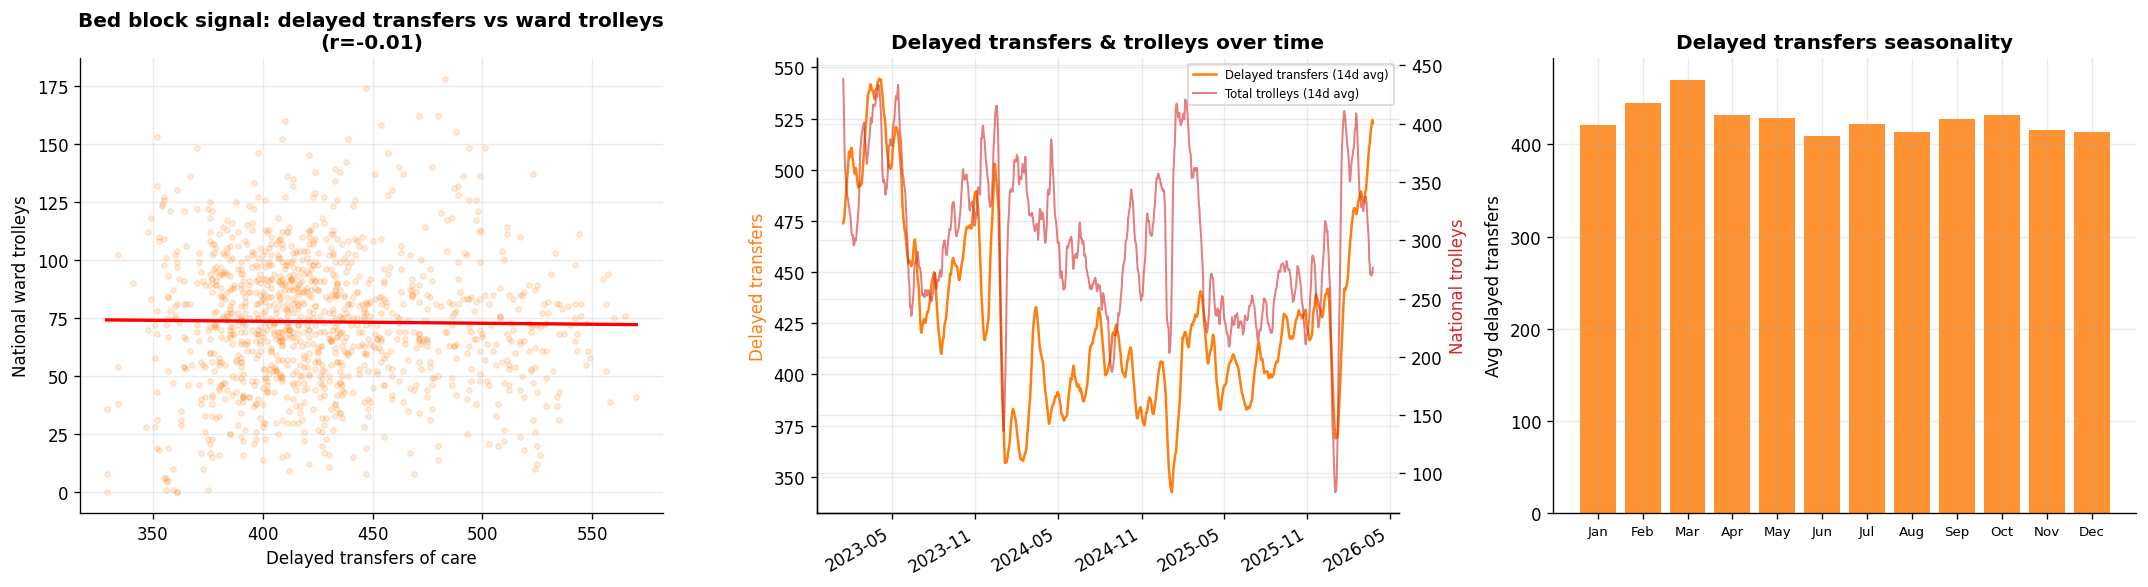

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: delayed vs ward trolleys
ax = axes[0]
ax.scatter(dtoc_merged['delayed_transfers'], dtoc_merged['ward_total'],
           alpha=0.15, s=10, color=PALETTE[1])
m, b, _, _, _ = stats.linregress(dtoc_merged['delayed_transfers'], dtoc_merged['ward_total'])
x = np.linspace(dtoc_merged['delayed_transfers'].min(), dtoc_merged['delayed_transfers'].max(), 100)
ax.plot(x, m * x + b, color='red', linewidth=2)
ax.set_xlabel('Delayed transfers of care')
ax.set_ylabel('National ward trolleys')
ax.set_title(f'Bed block signal: delayed transfers vs ward trolleys\n(r={r_dtoc_ward:.2f})', fontweight='bold')

# Middle: time series
ax2 = axes[1]
dtoc_ts = dtoc.set_index('report_date').sort_index()
ax2.plot(dtoc_ts.index, dtoc_ts['delayed_transfers'].rolling(14).mean(),
         color=PALETTE[1], linewidth=1.5, label='Delayed transfers (14d avg)')
ax2b = ax2.twinx()
ax2b.plot(dtoc_ts.index, dtoc_ts['total_trolleys'].rolling(14).mean(),
          color=PALETTE[3], linewidth=1.2, alpha=0.6, label='Total trolleys (14d avg)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.set_ylabel('Delayed transfers', color=PALETTE[1])
ax2b.set_ylabel('National trolleys', color=PALETTE[3])
ax2b.spines['top'].set_visible(False)
ax2.set_title('Delayed transfers & trolleys over time', fontweight='bold')
lines1, l1 = ax2.get_legend_handles_labels()
lines2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, l1 + l2, fontsize=7)

# Right: monthly seasonality
ax3 = axes[2]
ax3.bar(range(1, 13), [dtoc_monthly.get(m, 0) for m in range(1, 13)],
        color=PALETTE[1], alpha=0.85)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(month_names, fontsize=8)
ax3.set_ylabel('Avg delayed transfers')
ax3.set_title('Delayed transfers seasonality', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/s12_delayed_transfers.png', bbox_inches='tight')
plt.show()

---
## Section 13 — Waiting >24 Hours: The Patient Safety Metric
Using `waiting_24h` and `waiting_24h_75plus` (recovered from blobs).  
Patients waiting >24 hours is the primary patient safety and regulatory threshold.

In [27]:
w24 = nat[nat['waiting_24h'].notna()].copy()
w24['year']  = w24['report_date'].dt.year
w24['month'] = w24['report_date'].dt.month

r_w24, _ = stats.pearsonr(w24['waiting_24h'], w24['total_trolleys'])
print(f'waiting_24h ↔ total trolleys: r={r_w24:.3f}')

# Yearly trend
w24_yearly = w24[w24['year'].isin([2023, 2024, 2025])].groupby('year')[['waiting_24h', 'waiting_24h_75plus']].mean()
print('\nAvg patients waiting >24h by year:')
print(w24_yearly.round(1).to_string())

# Worst days by waiting_24h (patient safety angle)
worst_w24 = w24.nlargest(10, 'waiting_24h')[['report_date', 'waiting_24h', 'waiting_24h_75plus', 'total_trolleys']]
print('\nTop 10 days by patients waiting >24h:')
print(worst_w24.to_string(index=False))

# What % of trolleys are waiting >24h?
w24['pct_waiting_24h'] = w24['waiting_24h'] / w24['total_trolleys'] * 100
pct_trend = w24[w24['year'].isin([2023, 2024, 2025])].groupby('year')['pct_waiting_24h'].mean()
print('\n% of total trolleys waiting >24h by year:')
print(pct_trend.round(1).to_string())

waiting_24h ↔ total trolleys: r=0.883

Avg patients waiting >24h by year:
      waiting_24h  waiting_24h_75plus
year                                 
2023         61.4                 8.1
2024         49.7                 6.7
2025         46.0                 2.2

Top 10 days by patients waiting >24h:
report_date  waiting_24h  waiting_24h_75plus  total_trolleys
 2023-01-03          253                 NaN             804
 2023-12-11          194                44.0             576
 2025-02-04          187                21.0             617
 2023-01-04          174                 NaN             645
 2023-03-27          168                 NaN             541
 2023-01-02          167                 NaN             624
 2023-05-02          162                 NaN             576
 2023-11-06          159                15.0             465
 2025-01-13          159                23.0             475
 2023-05-08          154                 NaN             533

% of total trolleys waiti

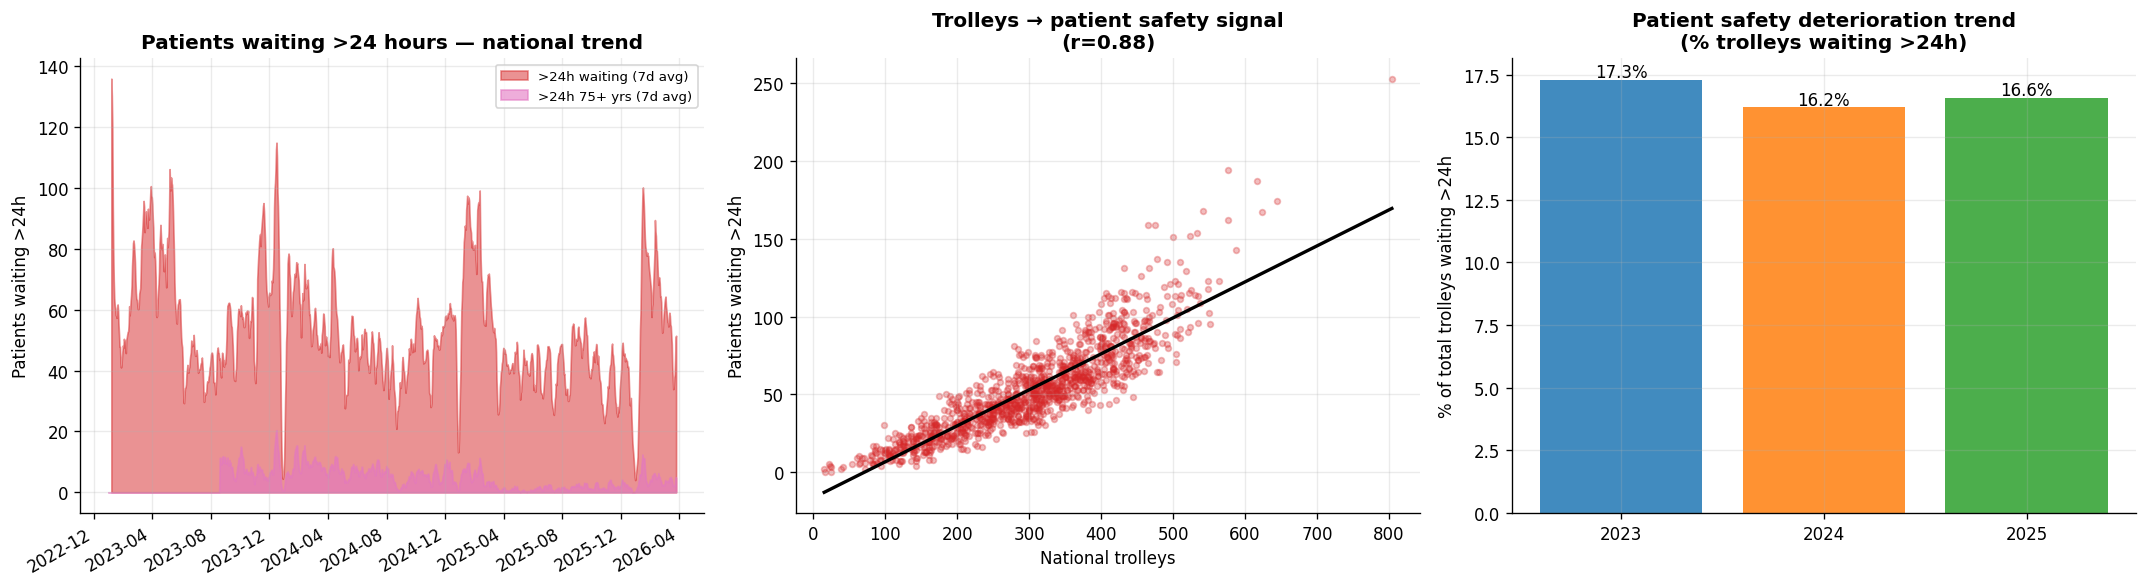

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: waiting_24h over time
ax = axes[0]
w24_ts = w24.set_index('report_date').sort_index()
ax.fill_between(w24_ts.index, w24_ts['waiting_24h'].rolling(7).mean(),
                alpha=0.5, color=PALETTE[3], label='>24h waiting (7d avg)')
if w24_ts['waiting_24h_75plus'].notna().sum() > 20:
    ax.fill_between(w24_ts.index, w24_ts['waiting_24h_75plus'].rolling(7).mean().fillna(0),
                    alpha=0.6, color=PALETTE[6], label='>24h 75+ yrs (7d avg)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('Patients waiting >24h')
ax.set_title('Patients waiting >24 hours — national trend', fontweight='bold')
ax.legend(fontsize=8)

# Middle: waiting_24h vs total trolleys scatter
ax2 = axes[1]
ax2.scatter(w24['total_trolleys'], w24['waiting_24h'], alpha=0.3, s=12, color=PALETTE[3])
m, b, _, _, _ = stats.linregress(w24['total_trolleys'], w24['waiting_24h'])
x = np.linspace(w24['total_trolleys'].min(), w24['total_trolleys'].max(), 100)
ax2.plot(x, m * x + b, color='black', linewidth=2)
ax2.set_xlabel('National trolleys')
ax2.set_ylabel('Patients waiting >24h')
ax2.set_title(f'Trolleys → patient safety signal\n(r={r_w24:.2f})', fontweight='bold')

# Right: % of trolleys waiting >24h by year
ax3 = axes[2]
valid_years = pct_trend.dropna()
bars = ax3.bar(valid_years.index, valid_years.values,
               color=[PALETTE[yr - 2023] for yr in valid_years.index], alpha=0.85)
for bar, val in zip(bars, valid_years.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontsize=10)
ax3.set_xticks(valid_years.index)
ax3.set_ylabel('% of total trolleys waiting >24h')
ax3.set_title('Patient safety deterioration trend\n(% trolleys waiting >24h)', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/s13_waiting_24h.png', bbox_inches='tight')
plt.show()

---
## Summary of Key Findings
Run the cell below to print a consolidated findings summary.

In [29]:
print('=' * 65)
print('HSE UEC DEEP DIVE — KEY FINDINGS')
print('=' * 65)

print(f'''
S1  Day-after holiday:
    T+1 lift = +{lift_pct:.1f}% vs matched non-holiday control.
    Worst holiday: {by_hol.index[0]} ({by_hol.iloc[0]:.0f} trolleys day after).

S2  Hospital trajectories:
    {(traj["slope"] > 0).sum()} hospitals getting worse, {(traj["slope"] < 0).sum()} improving 2023→2025.
    Worst deteriorating: {traj.nlargest(1,"slope")["hospital"].iloc[0]}.
    Best improving: {traj.nsmallest(1,"slope")["hospital"].iloc[0]}.

S6  Weather (new signals):
    Best predictor after month-adjustment: {pcorr_df["partial_r"].abs().idxmax()}
    (partial r = {pcorr_df["partial_r"].abs().max():.3f}).

S7  Worst days:
    Most consistent crisis driver: {cons_df.index[0]} ({cons_df.iloc[0]} / 20 worst days).

S9  Volatility:
    Most chaotic high-pressure:
    {vol[vol["quadrant"]=="High pressure + Chaotic"].nlargest(1,"cv")["hospital"].values}

S11 Surge capacity:
    Correlation with trolleys: r={r_surge:.2f}.
    Peak activation month: {surge_monthly.idxmax()} ({surge_monthly.max():.0f} avg surge).

S12 Delayed transfers (bed block):
    Correlation with ward trolleys: r={r_dtoc_ward:.2f}.
    Avg delayed transfers 2025: {dtoc_yearly.get(2025, float("nan")):.0f}.

S13 Waiting >24h (patient safety):
    Correlation with total trolleys: r={r_w24:.2f}.
    % waiting >24h in {int(pct_trend.dropna().index[-1])}: {pct_trend.dropna().iloc[-1]:.1f}%.
''')
print('=' * 65)

HSE UEC DEEP DIVE — KEY FINDINGS

S1  Day-after holiday:
    T+1 lift = +-18.4% vs matched non-holiday control.
    Worst holiday: Lá Fhéile Bríde (496 trolleys day after).

S2  Hospital trajectories:
    6 hospitals getting worse, 21 improving 2023→2025.
    Worst deteriorating: Galway University Hospital.
    Best improving: Tallaght University Hospital.

S6  Weather (new signals):
    Best predictor after month-adjustment: pres
    (partial r = 0.082).

S7  Worst days:
    Most consistent crisis driver: UH Limerick (20 / 20 worst days).

S9  Volatility:
    Most chaotic high-pressure:
    ["St Luke's General Hospital Kilkenny"]

S11 Surge capacity:
    Correlation with trolleys: r=0.61.
    Peak activation month: 1 (480 avg surge).

S12 Delayed transfers (bed block):
    Correlation with ward trolleys: r=-0.01.
    Avg delayed transfers 2025: 410.

S13 Waiting >24h (patient safety):
    Correlation with total trolleys: r=0.88.
    % waiting >24h in 2025: 16.6%.

